# 抖音“日本修宪”数据处理与初步分析展示

本 Notebook 用于组会展示本周完成的数据处理、BERTopic 聚类实验、topic 清洗、以及基础网络层分析结果。

核心原则：原始数据库和原始媒体文件不直接修改；后续分析使用 working / processed / analysis_inputs 中的派生数据。

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

PROJECT_ROOT = Path('..').resolve()
DATA = PROJECT_ROOT / 'data'
PROCESSED = DATA / 'processed'

STAGE1 = PROCESSED / 'bertopic_evaluation' / 'stage1'
STAGE2 = PROCESSED / 'bertopic_evaluation' / 'stage2'
FINAL_TOPIC = PROCESSED / 'bertopic_posts' / 'final_mcs15_ms15_nn15_nc5'
TOPIC_VIZ = FINAL_TOPIC / 'visualizations'
ANALYSIS_INPUTS = PROCESSED / 'analysis_inputs'
NETWORK = PROCESSED / 'network_analysis'
NETWORK_VIZ = NETWORK / 'visualizations'

def show_image(path, width=None):
    display(Image(filename=str(path), width=width))

## 1. 本周工作流程

1. 保留 raw 数据不动，建立 working / processed 流程。
2. 清洗帖子文本，并将视频 ASR 转写文本合并到 BERTopic 输入文本。
3. 使用 BERTopic 做两阶段参数实验：先调 HDBSCAN，再调 UMAP。
4. 选择最终参数组：`n_neighbors=15, n_components=5, min_cluster_size=15, min_samples=15`。
5. 根据人工浏览结果，将 topic 8、22、27、28 标记为不参与后续分析。
6. 构建帖子和评论的统一分析入口表。
7. 构建基础网络分析表和可视化。

In [2]:
posts_input = pd.read_csv(ANALYSIS_INPUTS / 'posts_for_analysis_topic_labeled.csv', dtype=str)
comments_input = pd.read_csv(ANALYSIS_INPUTS / 'comments_for_analysis_topic_labeled.csv', dtype=str)
topic_results = pd.read_csv(FINAL_TOPIC / 'topic_results.csv', dtype=str)

summary = pd.DataFrame({
    'item': [
        'final_topic_results_rows',
        'posts_include_true',
        'posts_include_false',
        'comments_include_true',
        'comments_include_false',
        'not_clustered_posts_topic_empty',
        'noise_posts_topic_minus_1',
    ],
    'value': [
        len(topic_results),
        int((posts_input['include_in_analysis'] == 'true').sum()),
        int((posts_input['include_in_analysis'] == 'false').sum()),
        int((comments_input['include_in_analysis'] == 'true').sum()),
        int((comments_input['include_in_analysis'] == 'false').sum()),
        int(topic_results['topic'].fillna('').str.strip().eq('').sum()),
        int(topic_results['topic'].fillna('').str.strip().eq('-1').sum()),
    ]
})
summary

,item,value
0,final_topic_results_rows,3543
1,posts_include_true,3370
2,posts_include_false,173
3,comments_include_true,1135397
4,comments_include_false,43681
5,not_clustered_posts_topic_empty,26
6,noise_posts_topic_minus_1,1141


## 2. BERTopic 参数实验

第一阶段固定 UMAP，比较 HDBSCAN 的 `min_cluster_size` 和 `min_samples`。主要观察离群率、DBCV、silhouette 等指标。

第二阶段固定 HDBSCAN = 15/15，比较 UMAP 的 `n_neighbors` 和 `n_components`。最终选择 A 组：`nn15 / nc5`。

In [16]:
stage1 = pd.read_csv(STAGE1 / 'stage1_results.csv')
stage2 = pd.read_csv(STAGE2 / 'stage2_results.csv')

display(Markdown('### Stage 1: DBCV Top 5'))
display(stage1.sort_values('dbcv', ascending=False).head(5))

display(Markdown('### Stage 2: DBCV Top 5'))
display(stage2.sort_values('dbcv', ascending=False).head(5))

### Stage 1: DBCV Top 5

,min_cluster_size,min_samples,topic_count,outlier_rate,dbcv,silhouette,davies_bouldin
2,5,10,66,0.351436,0.535646,0.574984,0.473873
6,8,10,60,0.348308,0.530154,0.603532,0.455187
1,5,5,140,0.376173,0.527413,0.599414,0.498198
10,10,10,57,0.339778,0.520267,0.592391,0.474112
3,5,15,38,0.332386,0.511618,0.597271,0.437633


### Stage 2: DBCV Top 5

,run_id,candidate_id,umap_n_neighbors,umap_n_components,umap_min_dist,umap_metric,hdbscan_min_cluster_size,hdbscan_min_samples,topic_count,outlier_rate,dbcv,silhouette,davies_bouldin,is_pareto,is_candidate
10,run_011_nn50_nc10_mcs15_ms15,D,50,10,0.0,cosine,15,15,29,0.422804,0.590117,0.638854,0.483077,True,True
8,run_009_nn30_nc15_mcs15_ms15,B,30,15,0.0,cosine,15,15,31,0.388115,0.567494,0.612047,0.479366,True,True
7,run_008_nn30_nc10_mcs15_ms15,F,30,10,0.0,cosine,15,15,29,0.385840,0.541732,0.610207,0.490946,True,True
11,run_012_nn50_nc15_mcs15_ms15,NaN,50,15,0.0,cosine,15,15,29,0.430765,0.531655,0.619339,0.537911,False,False
2,run_003_nn10_nc15_mcs15_ms15,C,10,15,0.0,cosine,15,15,38,0.349161,0.517174,0.614648,0.475721,True,True


### Stage 1 Heatmaps

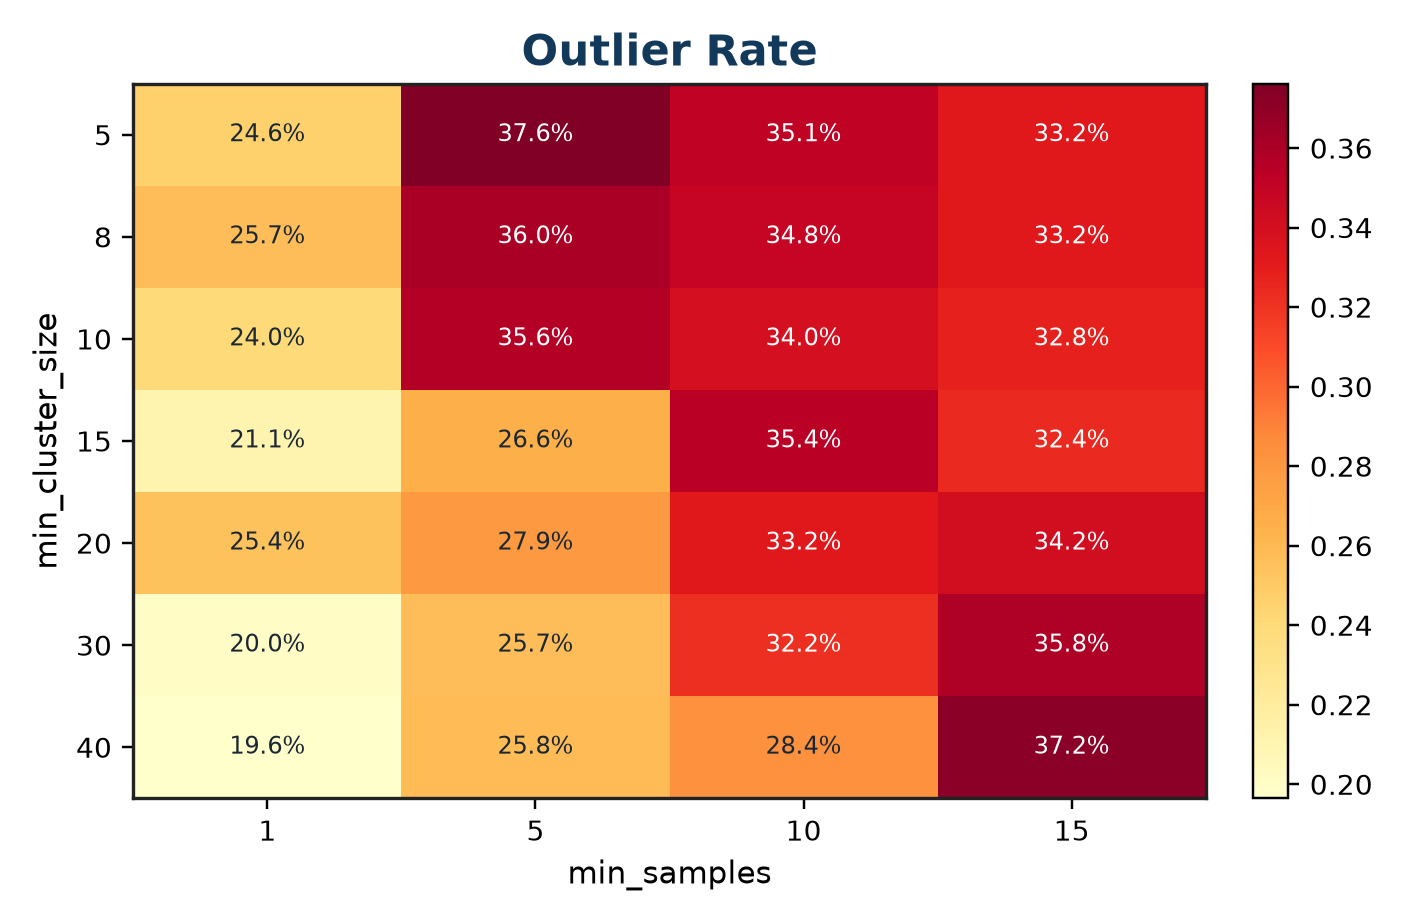

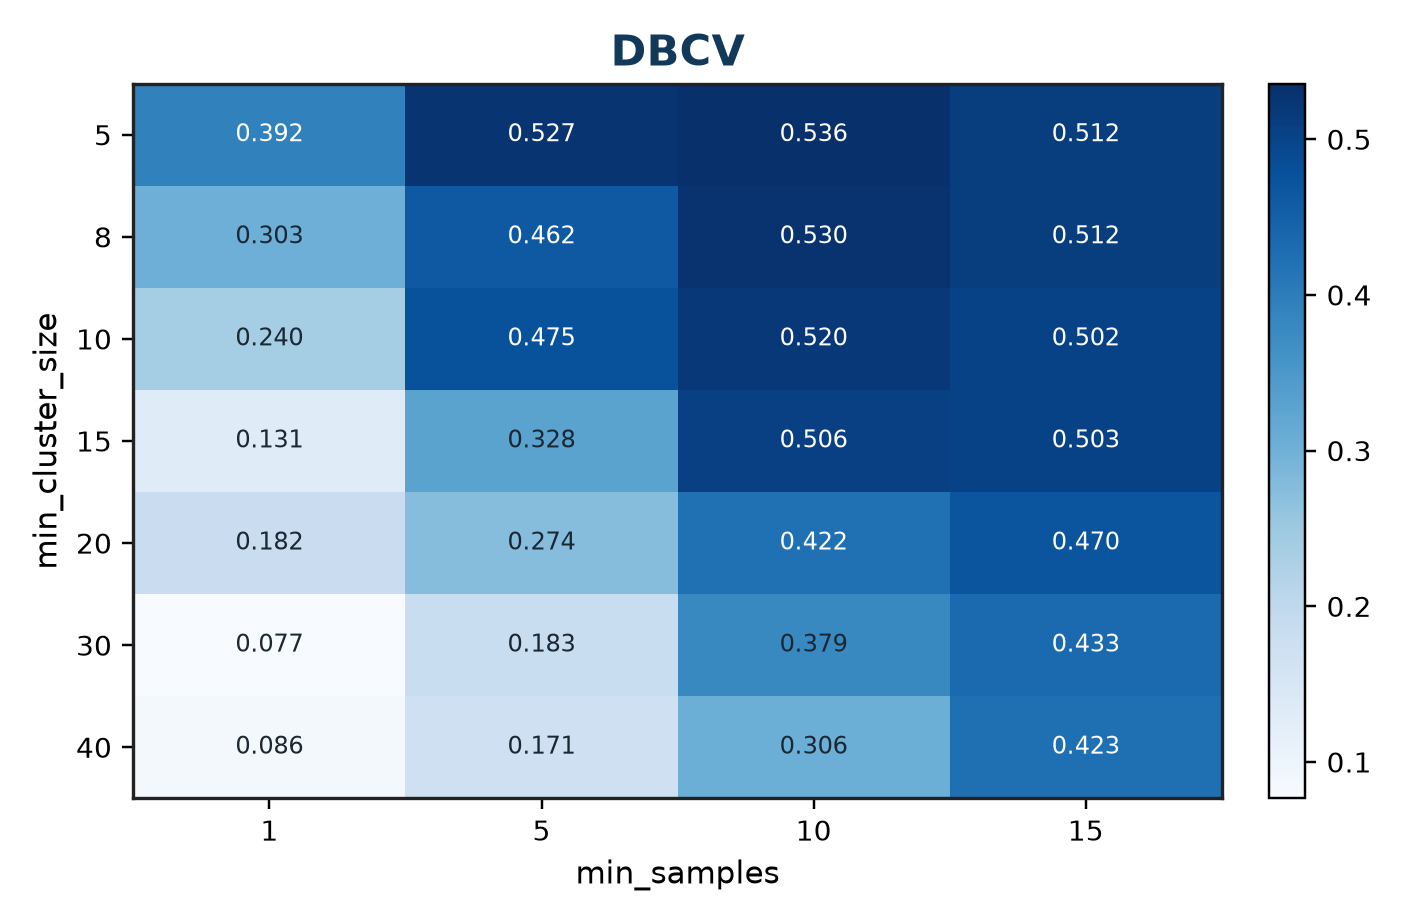

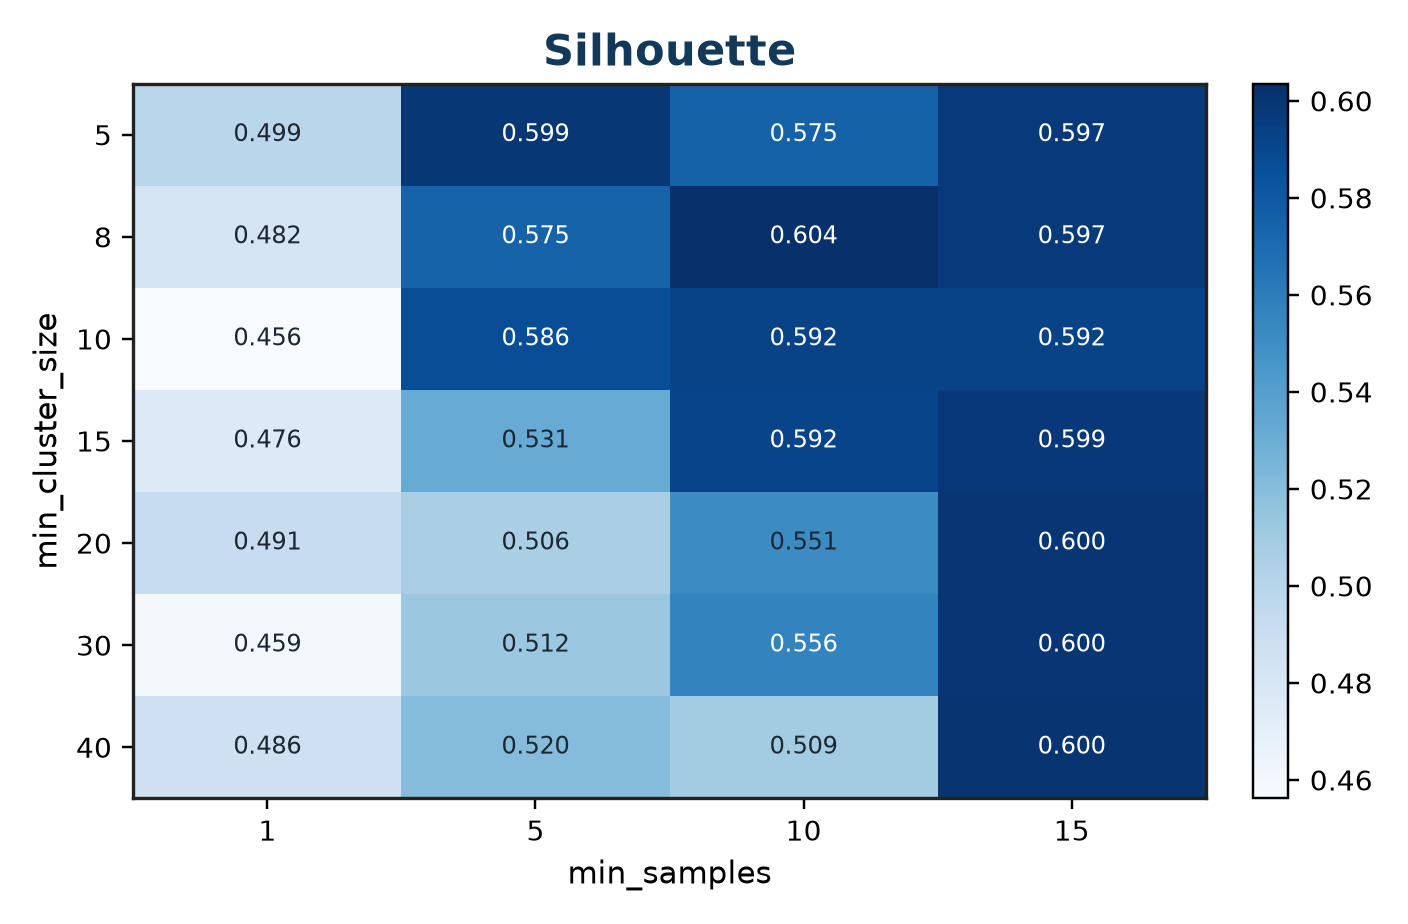

In [4]:
show_image(STAGE1 / 'stage1_outlier_heatmap.png', width=900)
show_image(STAGE1 / 'stage1_dbcv_heatmap.png', width=900)
show_image(STAGE1 / 'stage1_silhouette_heatmap.png', width=900)

### Stage 2 Candidate Scatter

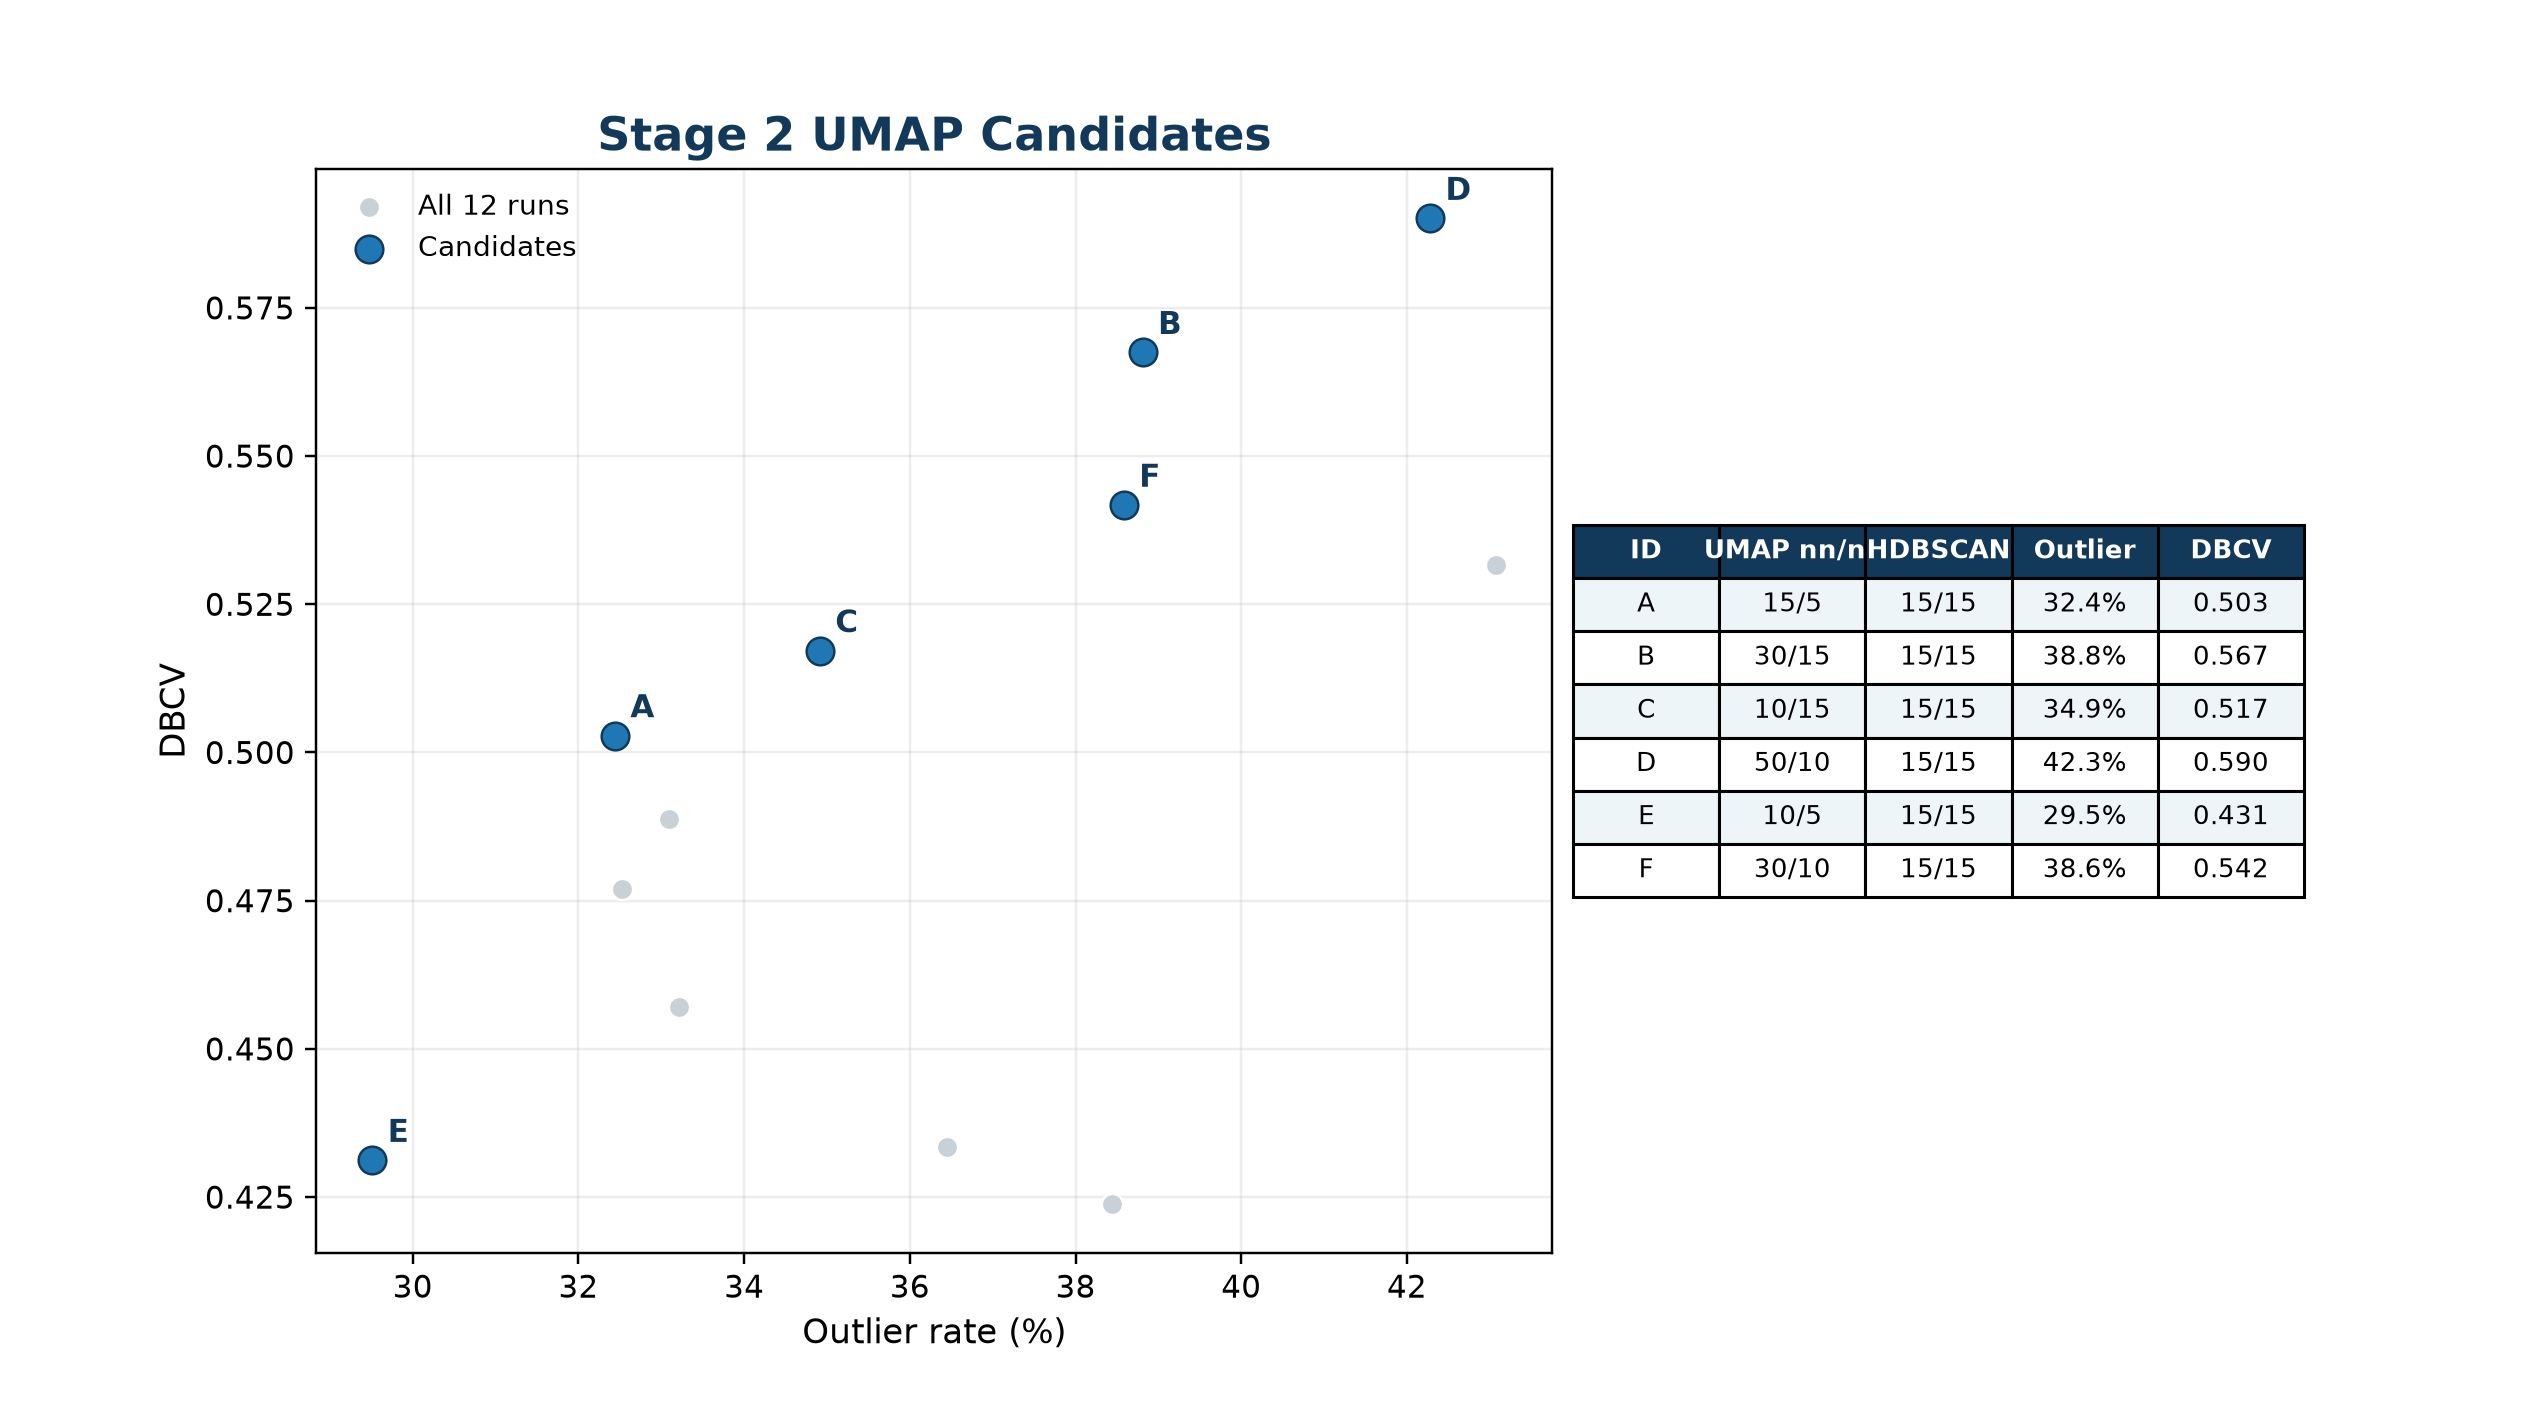

In [5]:
show_image(STAGE2 / 'stage2_candidate_scatter.png', width=900)

## 3. 最终 BERTopic 结果

最终参数：

- Embedding: `paraphrase-multilingual-MiniLM-L12-v2`
- UMAP: `n_neighbors=15`, `n_components=5`, `min_dist=0.0`, `metric=cosine`
- HDBSCAN: `min_cluster_size=15`, `min_samples=15`
- `nr_topics=None`
- Topic 表示：jieba 分词 + `ngram_range=(1,2)`

In [6]:
final_summary = pd.read_csv(FINAL_TOPIC / 'topic_summary.csv', dtype=str)
final_results = pd.read_csv(FINAL_TOPIC / 'topic_results.csv', dtype=str)

pd.DataFrame({
    'metric': ['rows', 'clustered_rows', 'topic_-1_rows', 'non_noise_topic_count'],
    'value': [
        len(final_results),
        int(final_results['topic'].fillna('').str.strip().ne('').sum()),
        int(final_results['topic'].fillna('').str.strip().eq('-1').sum()),
        int(final_summary['topic'].astype(str).ne('-1').sum()),
    ]
})

,metric,value
0,rows,3543
1,clustered_rows,3517
2,topic_-1_rows,1141
3,non_noise_topic_count,32


In [7]:
display(final_summary.head(12))

,topic,count,topic_name,top_words,example_text_1,example_text_2,example_text_3
0,-1,1141,-1_日本_中国_美国_就是,日本 中国 美国 就是 一个 宪法 这个 我们 他们 国家,中国外交部发言人郭嘉昆13日主持例行记者会。 有记者提问：自从高市政府宣布推动修宪以来，日本...,猝不及防 日本“对韩强硬内阁”上线 专家暗示安倍很快将有大动作,安倍去世刺激日本极端右翼，一意孤行奔向黑暗，作死条件已经到位 #安倍晋三去世#日本极端右翼#...
1,0,292,0_日本_日元_经济_就是,日本 日元 经济 就是 美国 一个 现在 全球 这个 已经,10月28日报道，#日本一村庄缝人偶缓解孤独 ：村民不超过60人，人偶数量已经超过村民人数。,听大侄子聊日本 #日本 #中日 #公知 #正能量,危险信号频发！日本当年如何滑入战争深渊？历史悲剧会重演吗？
2,1,269,1_中国_日本_高市_早苗,中国 日本 高市 早苗 台湾 中方 言论 高市 早苗 台海 我们,"日防卫大臣抗议中国""侵犯""领空，网友:""应该严格执行波茨坦公告!"" #日本 #波茨坦公告",外媒：日本右翼发文“打倒中华帝国霸权主义”告中华善良人民书 #军事 #Y9侦察机 #中日关系,日本威吓他国不许参加九三阅兵，有何心结？
3,2,188,2_有事_台湾_日本 有事_台湾 有事,有事 台湾 日本 有事 台湾 有事 日本 台灣 有事 就是 就是 日本 就是 有事 日本,这种败类的丑恶言行不值一评。#方浩明,田中劝告日本民众 田中劝告日本民众#田中裕之,日本就是自己和自己整急眼了 #日本 #台湾 #地缘政治
4,3,186,3_集会_民众_抗议_反对,集会 民众 抗议 反对 日本 民众 修宪 日本 高市 宪法 和平,日本京都市民在八坂神社举行游行：反对战争，要求保持宪法9条（“放弃战争”和“不保持战争力量”...,#五一假期回放 #全民怒吼！日本民众大规模抗议修宪 誓死守护和平宪法第九条！,【抖音独家】高市早苗强推修宪，5万日本人街头呐喊，誓死守护和 #硬核深度计划 #全球创作者计...
5,4,134,4_日本_防卫_军事_安保,日本 防卫 军事 安保 武器 和平 文件 国家 安全 突破,日本9万亿防卫费再创新高 究竟剑指何方？日本防卫重点曝光 日本防卫预算，今天公布了：冲上9万...,高市早苗公然叫嚣，为长期战争做准备，这回装都不装了！#军事科技#军事科普,日本防卫预算飙升突破红线，军事扩张野心昭然若揭
6,5,123,5_宪法_和平_日本_和平 宪法,宪法 和平 日本 和平 宪法 第九条 宪法 第九条 战争 放弃 修改 修宪,高市早苗似乎不知，联合国敌国条款仍然有效，日本可随时立正挨打#军事科普#军事科技#军事爱好者...,日本憋不住了，要闹事！中国危险了？#霞客来了 #朱霞 #国际局势分析 #日本,搞不明白，当初为什么日本《和平宪法》的修改权会放在日本手里？不应该由联合国主导，并且必须经几...
7,6,116,6_修宪_宪法_日本_高市,修宪 宪法 日本 高市 自民党 修改 和平 早苗 和平 宪法 美国,高市早苗要搞的事 修宪，扩军，借债，排外，放水… #硬核深度计划,高市早苗赌赢了，和平宪法或将失效，中方发来一句“警告”！#军事科技#军事科普,和平宪法松动，野心浮出水面
8,7,111,7_日本_自卫队_海上_导弹,日本 自卫队 海上 导弹 作战 海上 自卫队 能力 军事 日本自卫队 航母,导弹试射与军国幽灵：日本突破和平宪法的危机与中国应对,日本准航母出动，迈出成为航母前最后一步，下一个目标是钓鱼岛？ 在本土进行一系列改造之后，日本...,美国是如何一步一步夺取日本自卫队的控制权？#聊聊国际关系 #硬核深度计划#海峡新干线#谈锋评论
9,8,104,8_正当防卫_对方_还手_法律,正当防卫 对方 还手 法律 花山 不法侵害 制止 动漫 我们 可以,#向一代伟人致敬 #我们永远记得你 #精神永存 #信仰的力量 #伟大的领袖,#硬核饼干#日本,#游戏日常 #历史


### Topic Word Scores

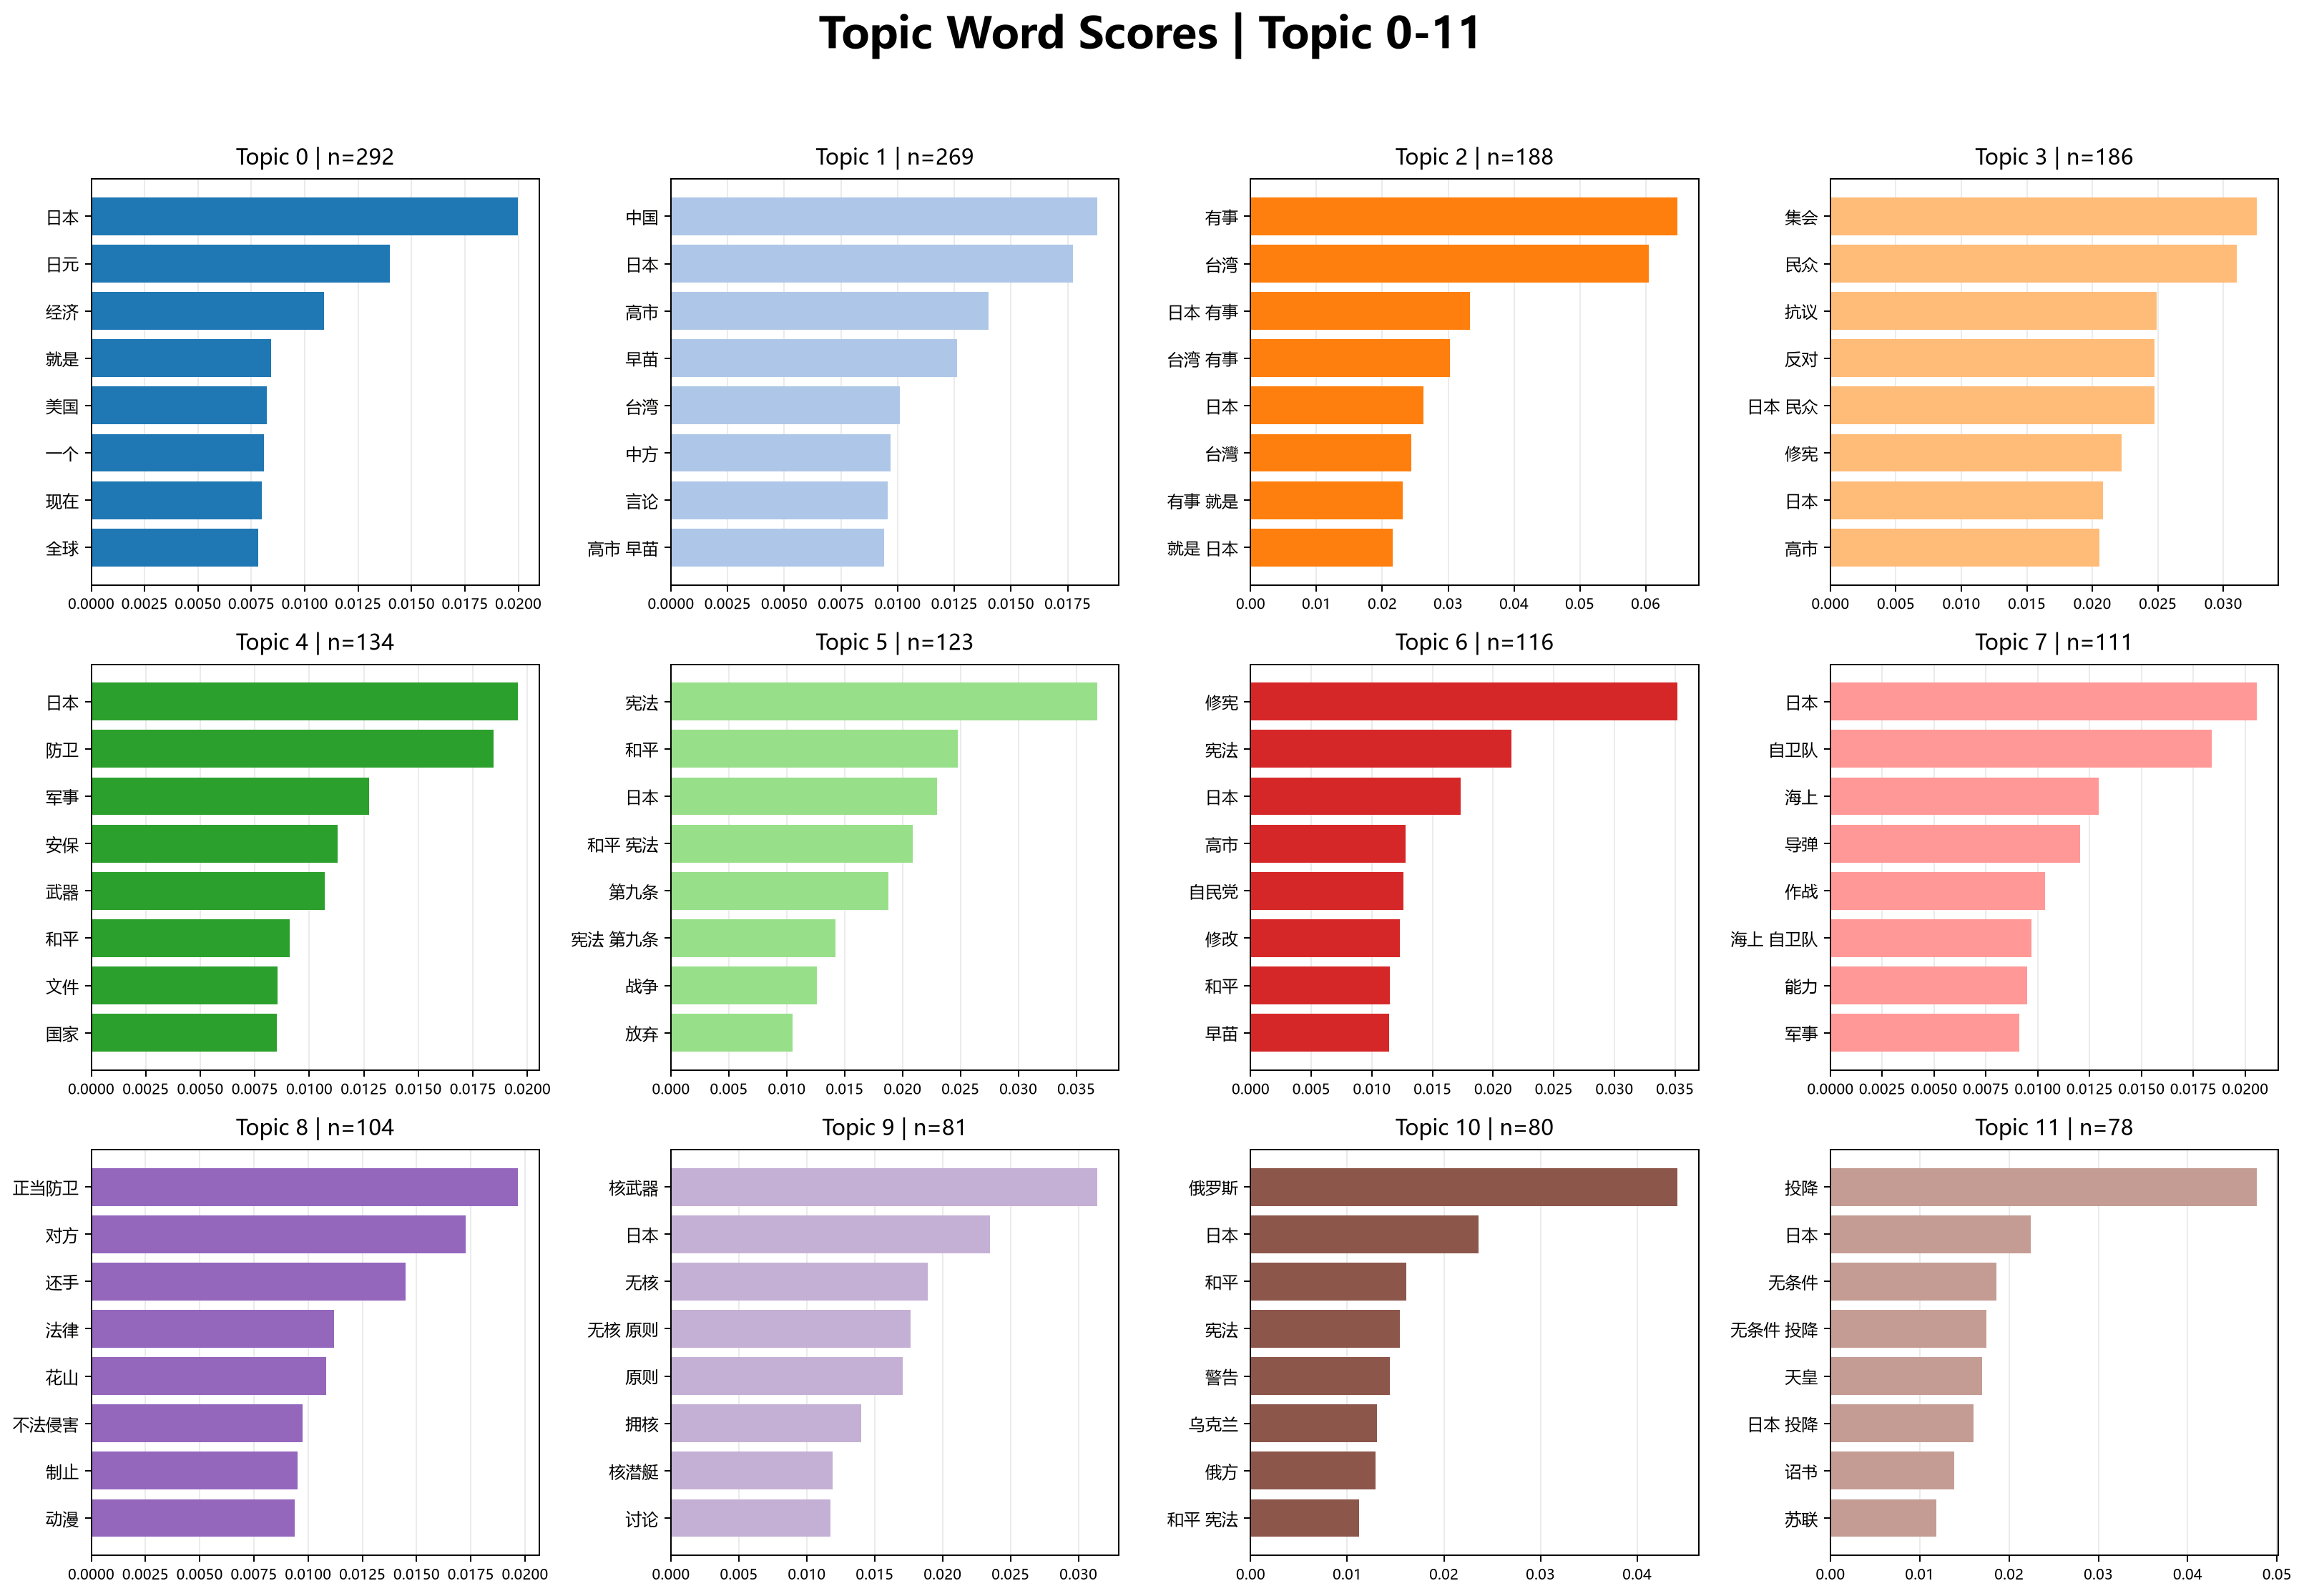

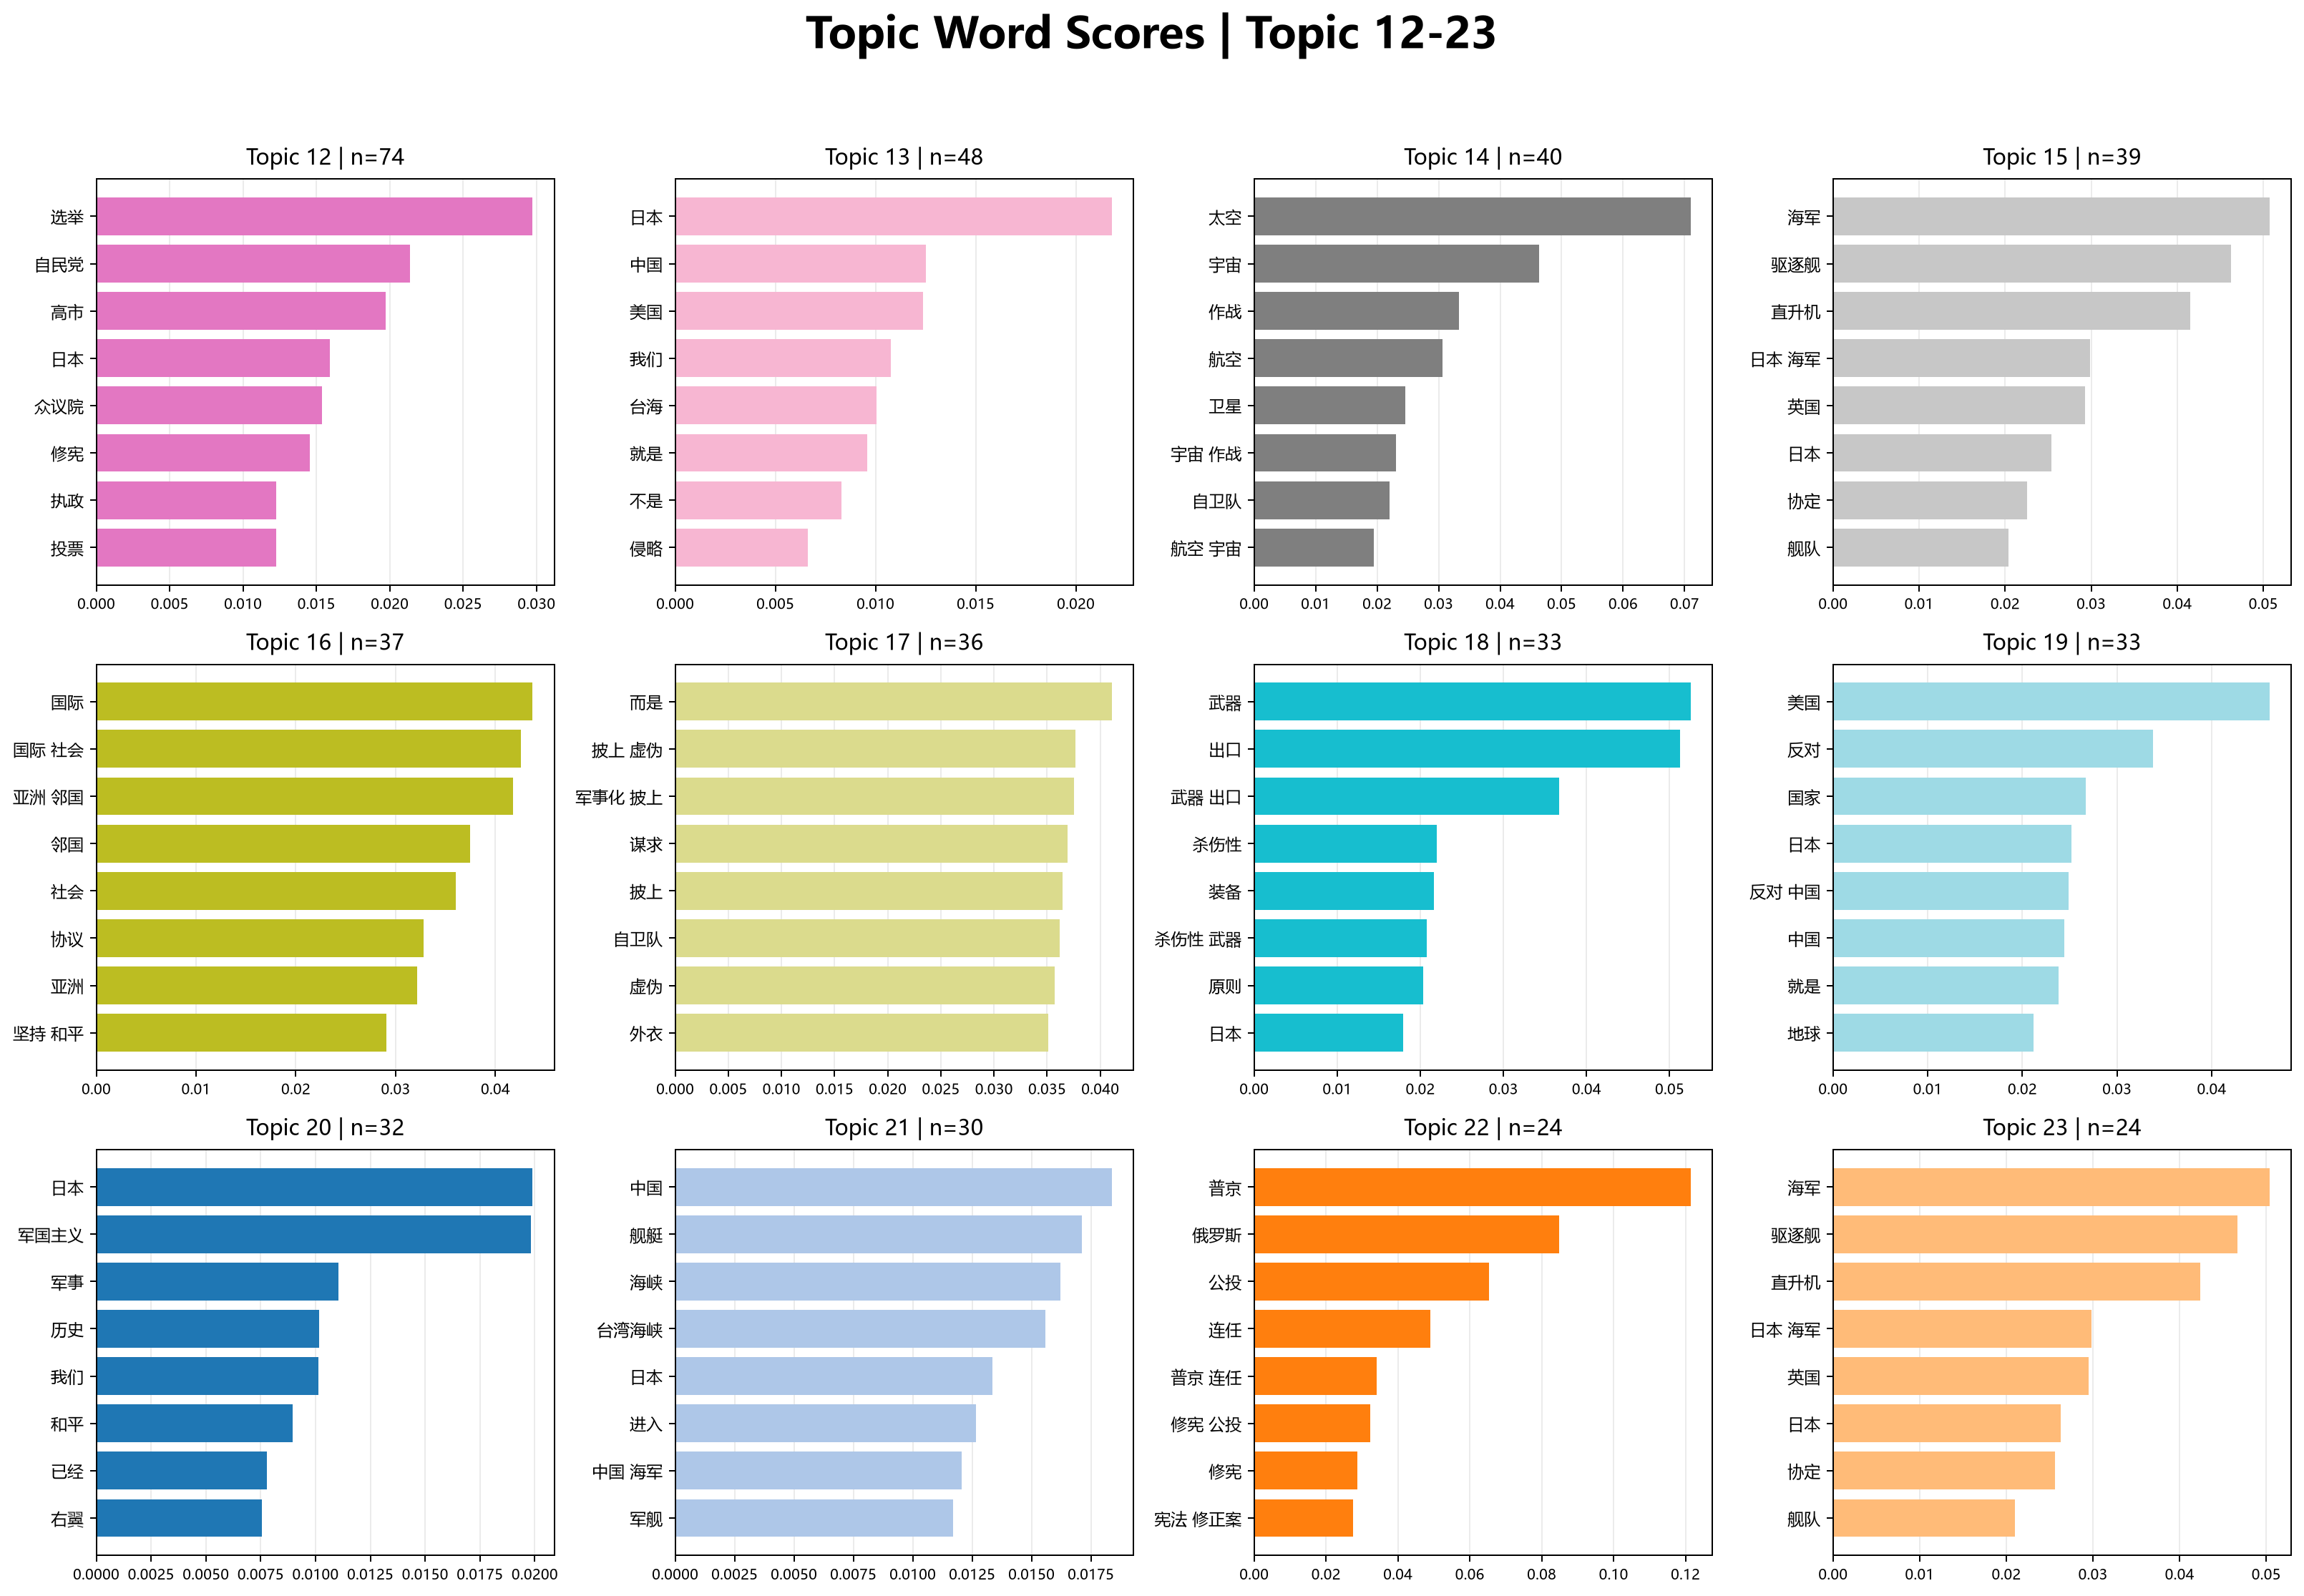

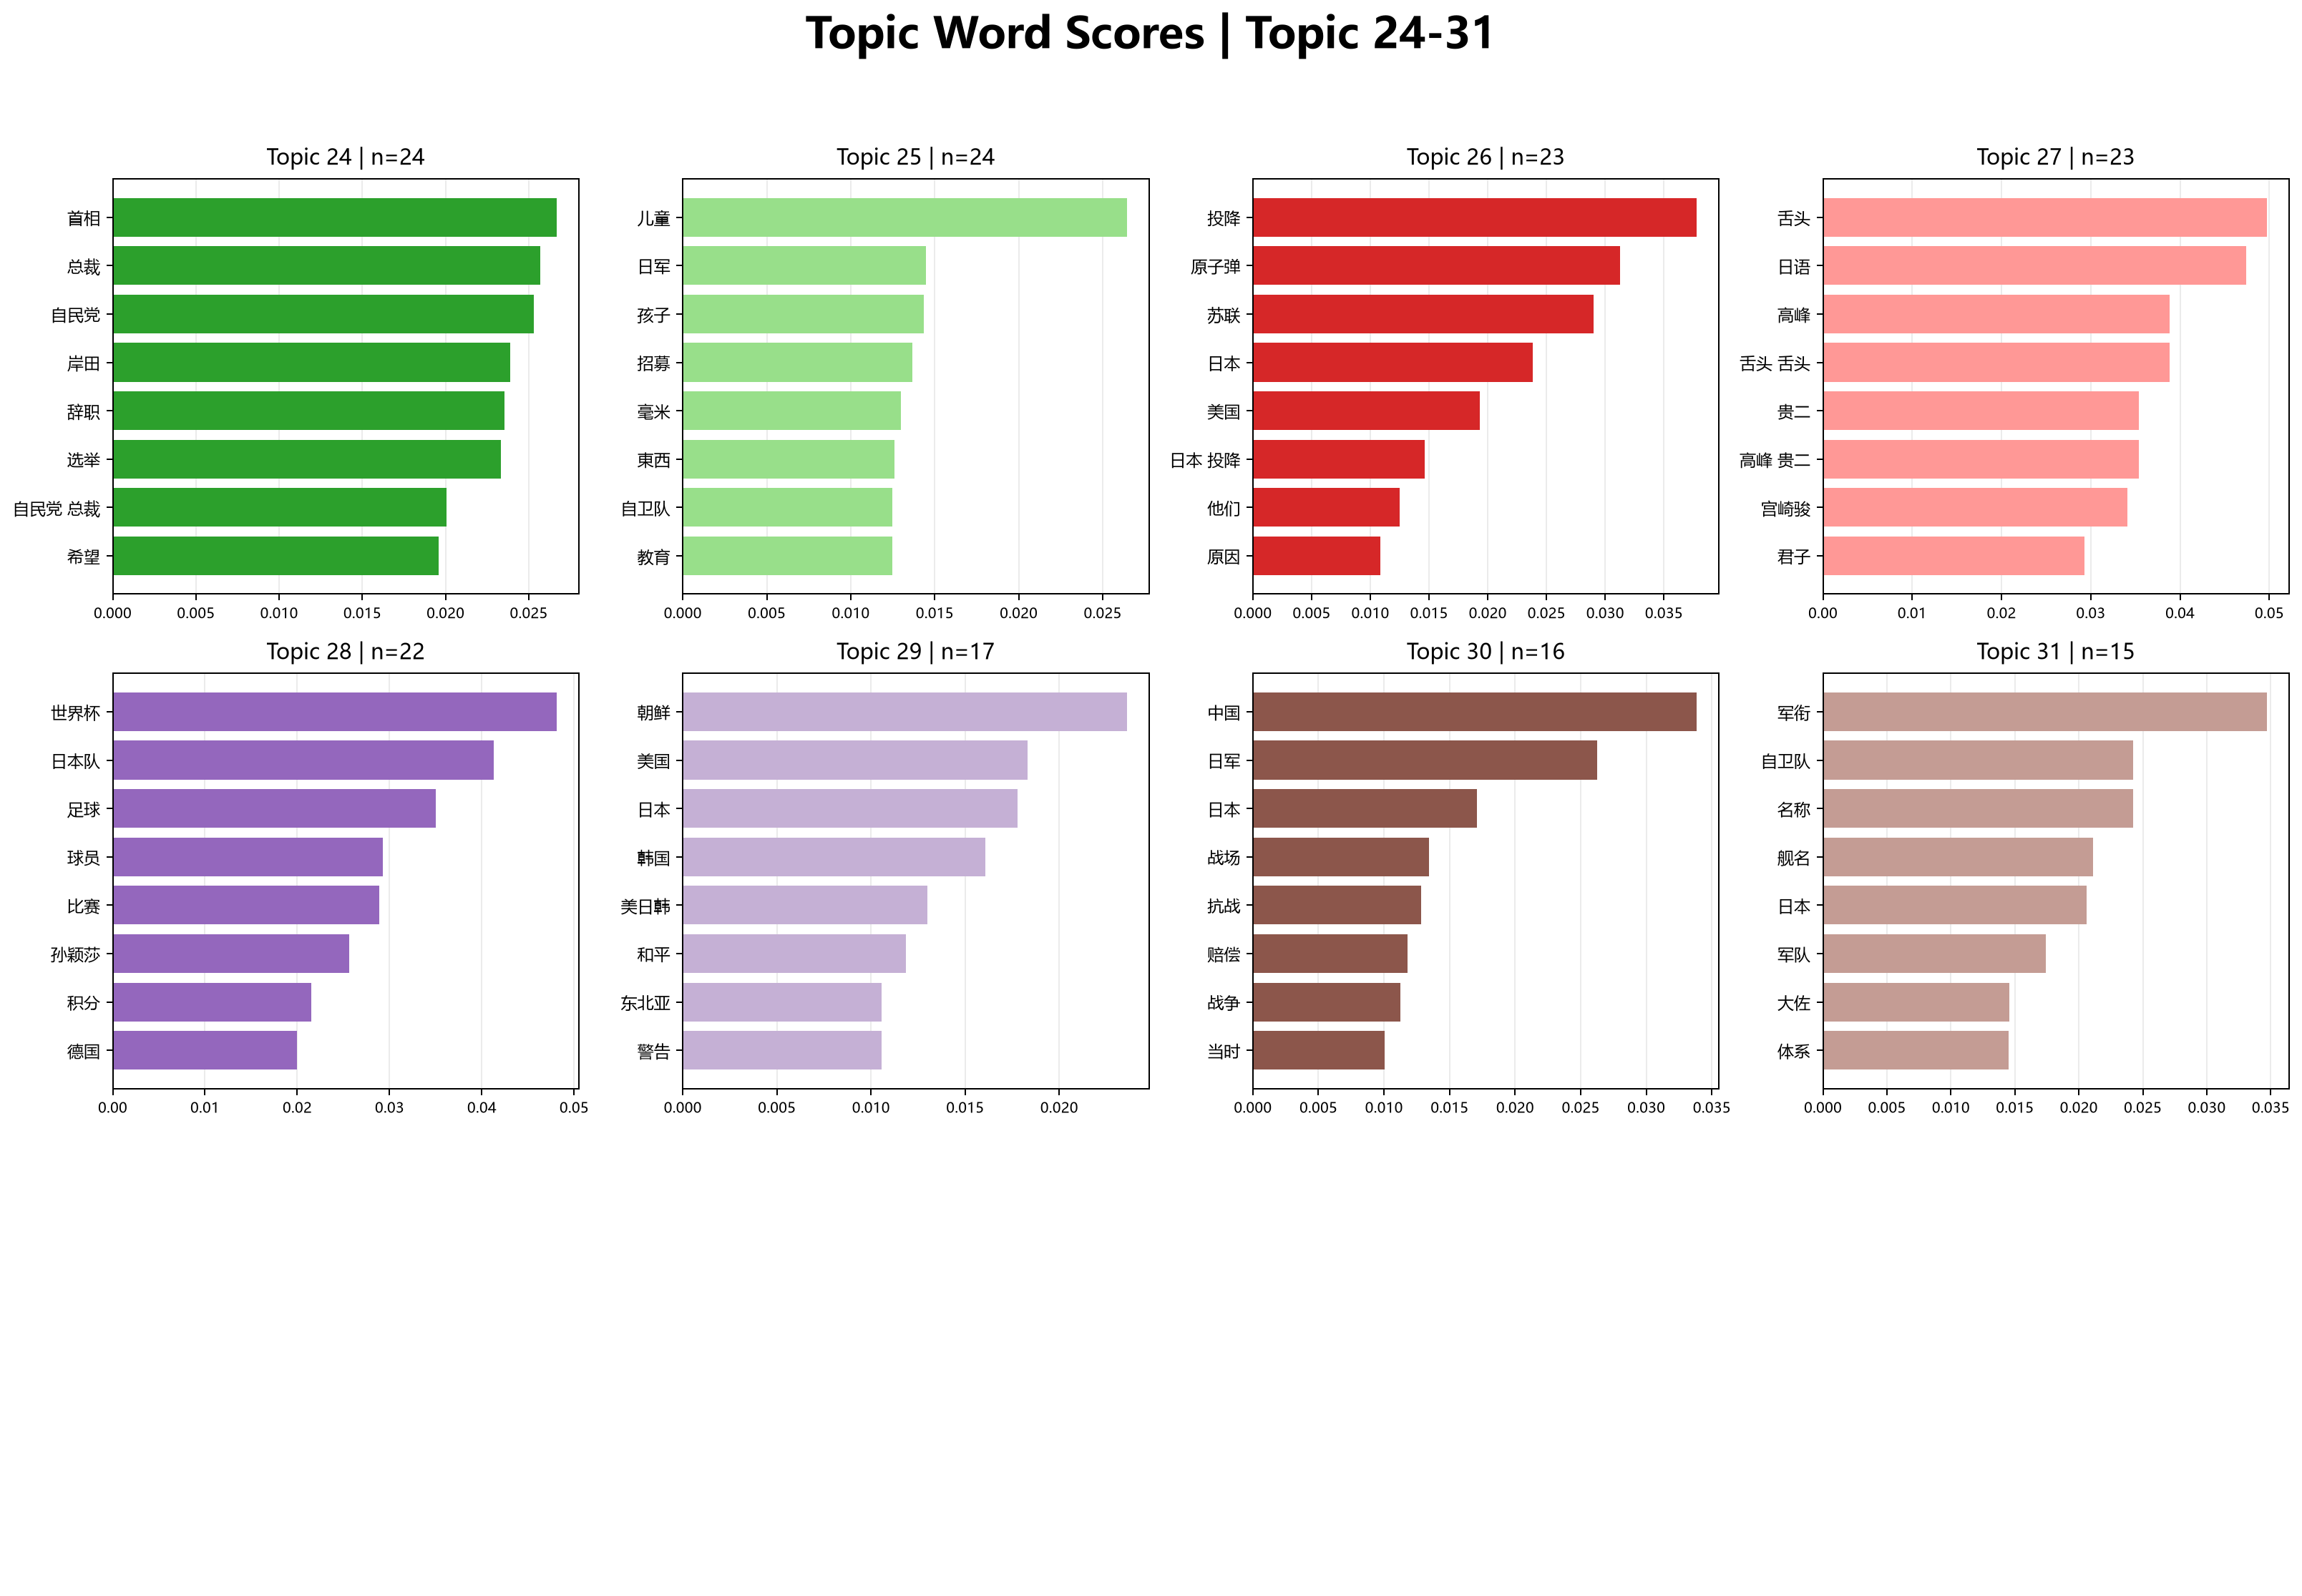

In [8]:
show_image(TOPIC_VIZ / 'topic_word_scores_0_11.png', width=1000)
show_image(TOPIC_VIZ / 'topic_word_scores_12_23.png', width=1000)
show_image(TOPIC_VIZ / 'topic_word_scores_24_31.png', width=1000)

### Topic 年度变化

横轴来自 `create_time`，即视频发布时间。

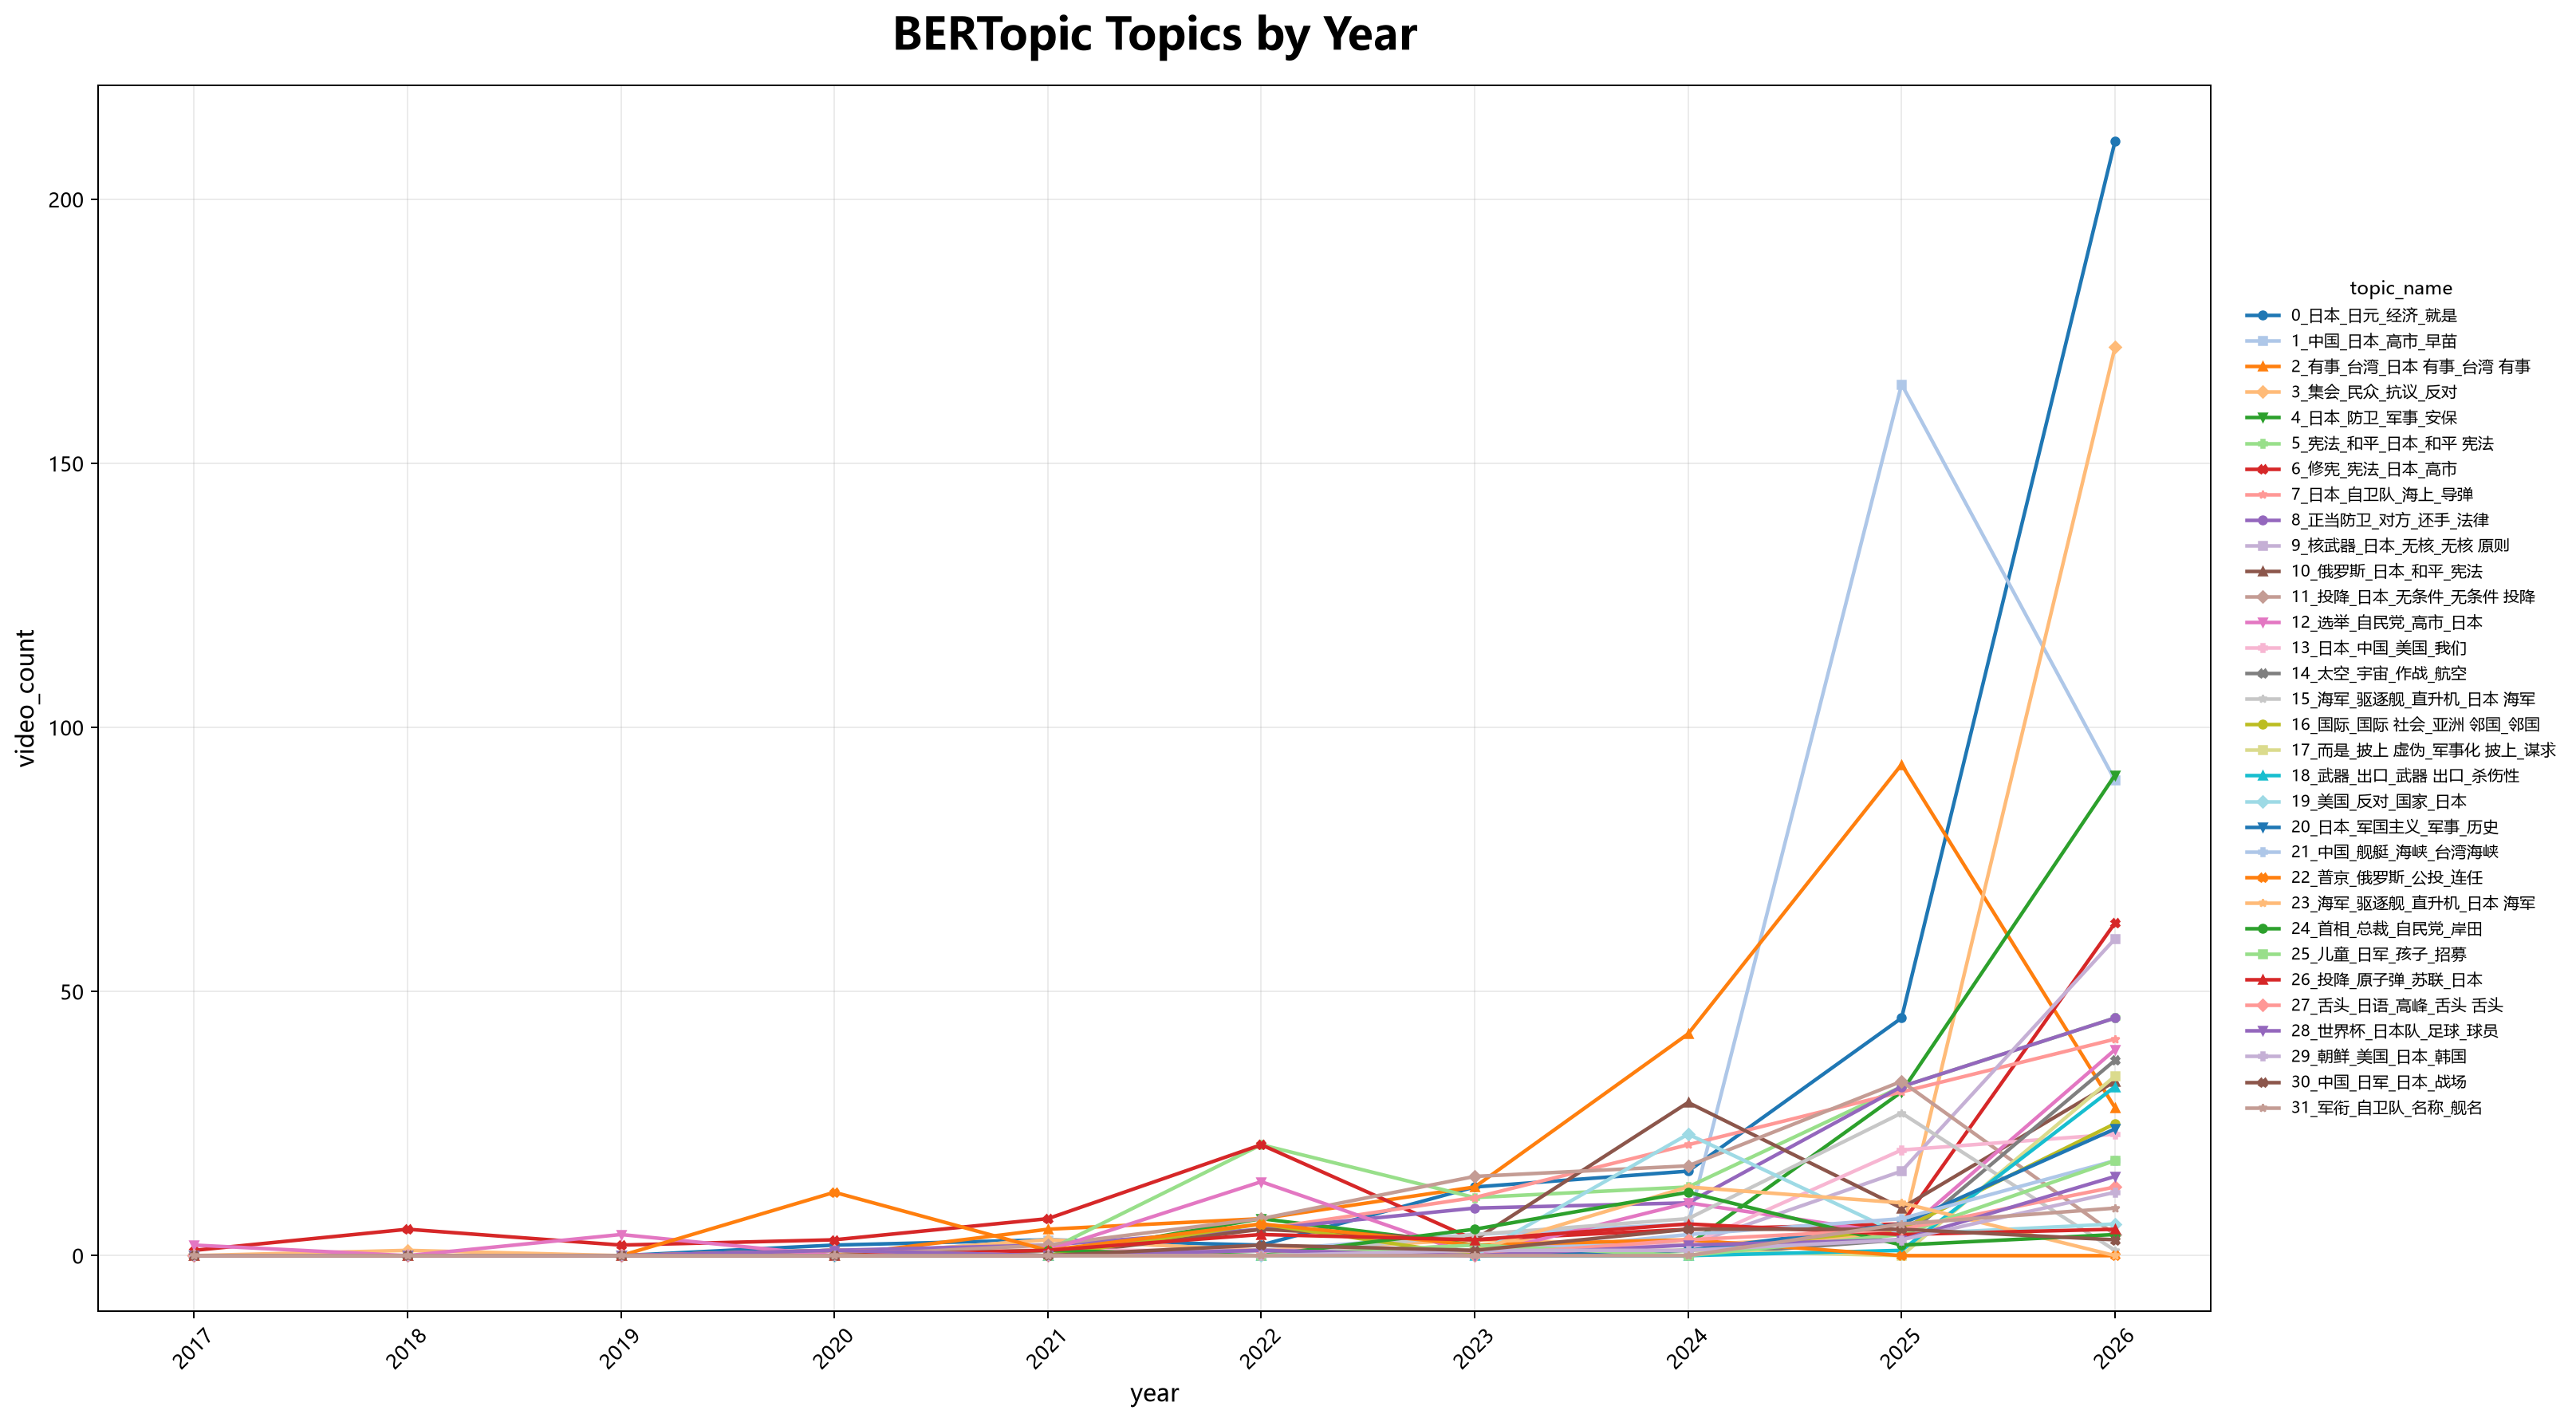

In [9]:
show_image(TOPIC_VIZ / 'topics_by_year_all_non_noise.png', width=1000)

## 4. Topic 清洗规则

人工浏览后，topic 8、22、27、28 被判定为明显无关。后续分析入口表保留所有行，但新增 `include_in_analysis` 标签：

- topic 8、22、27、28：`false`
- 其他 topic、topic=-1、未参与聚类的空 topic：`true`

后续网络分析和文本分析统一筛选 `include_in_analysis == true`。

In [10]:
posts_input['include_in_analysis'].value_counts(dropna=False).rename_axis('include_in_analysis').reset_index(name='post_count')

,include_in_analysis,post_count
0,true,3370
1,false,173


In [11]:
comments_input['include_in_analysis'].value_counts(dropna=False).rename_axis('include_in_analysis').reset_index(name='comment_count')

,include_in_analysis,comment_count
0,true,1135397
1,false,43681


## 5. 基础网络层分析

当前网络分析先做两个层面：

1. 用户角色：评论用户是否也是发帖用户。
2. 用户-视频二分关系：谁评论了哪个视频。

In [12]:
network_summary = pd.read_csv(NETWORK / 'network_summary.csv')
network_summary

,metric,value
0,post_count,3370
1,comment_count,1135397
2,video_count,3370
3,post_author_count,2096
4,comment_user_count,970679
5,all_user_count,972484
6,post_only_user_count,1805
7,comment_only_user_count,970388
8,both_post_and_comment_user_count,291
9,user_video_edge_count,1067844


### 网络分析可视化

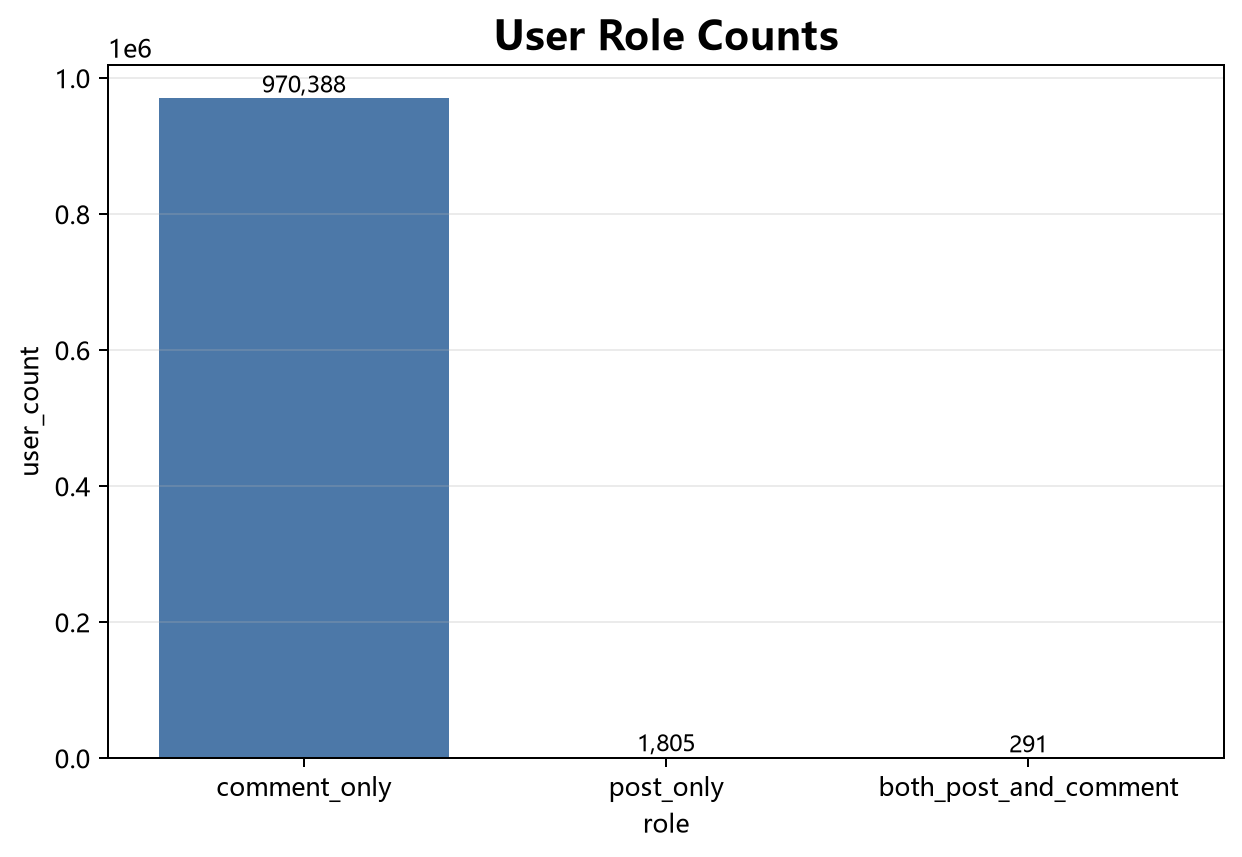

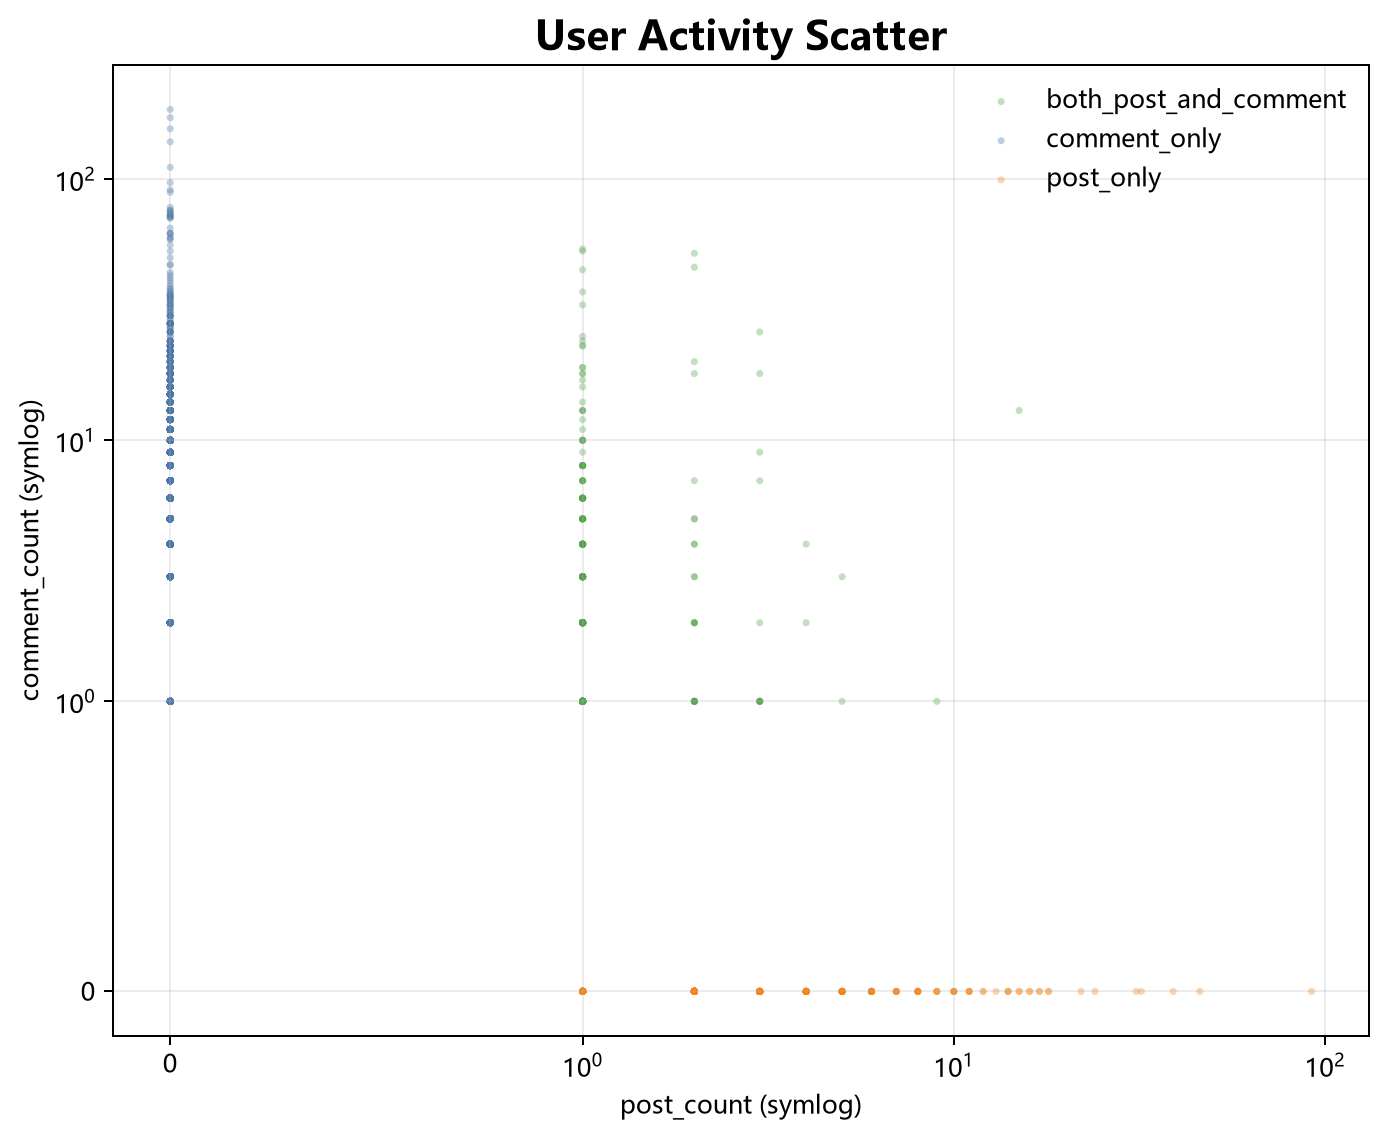

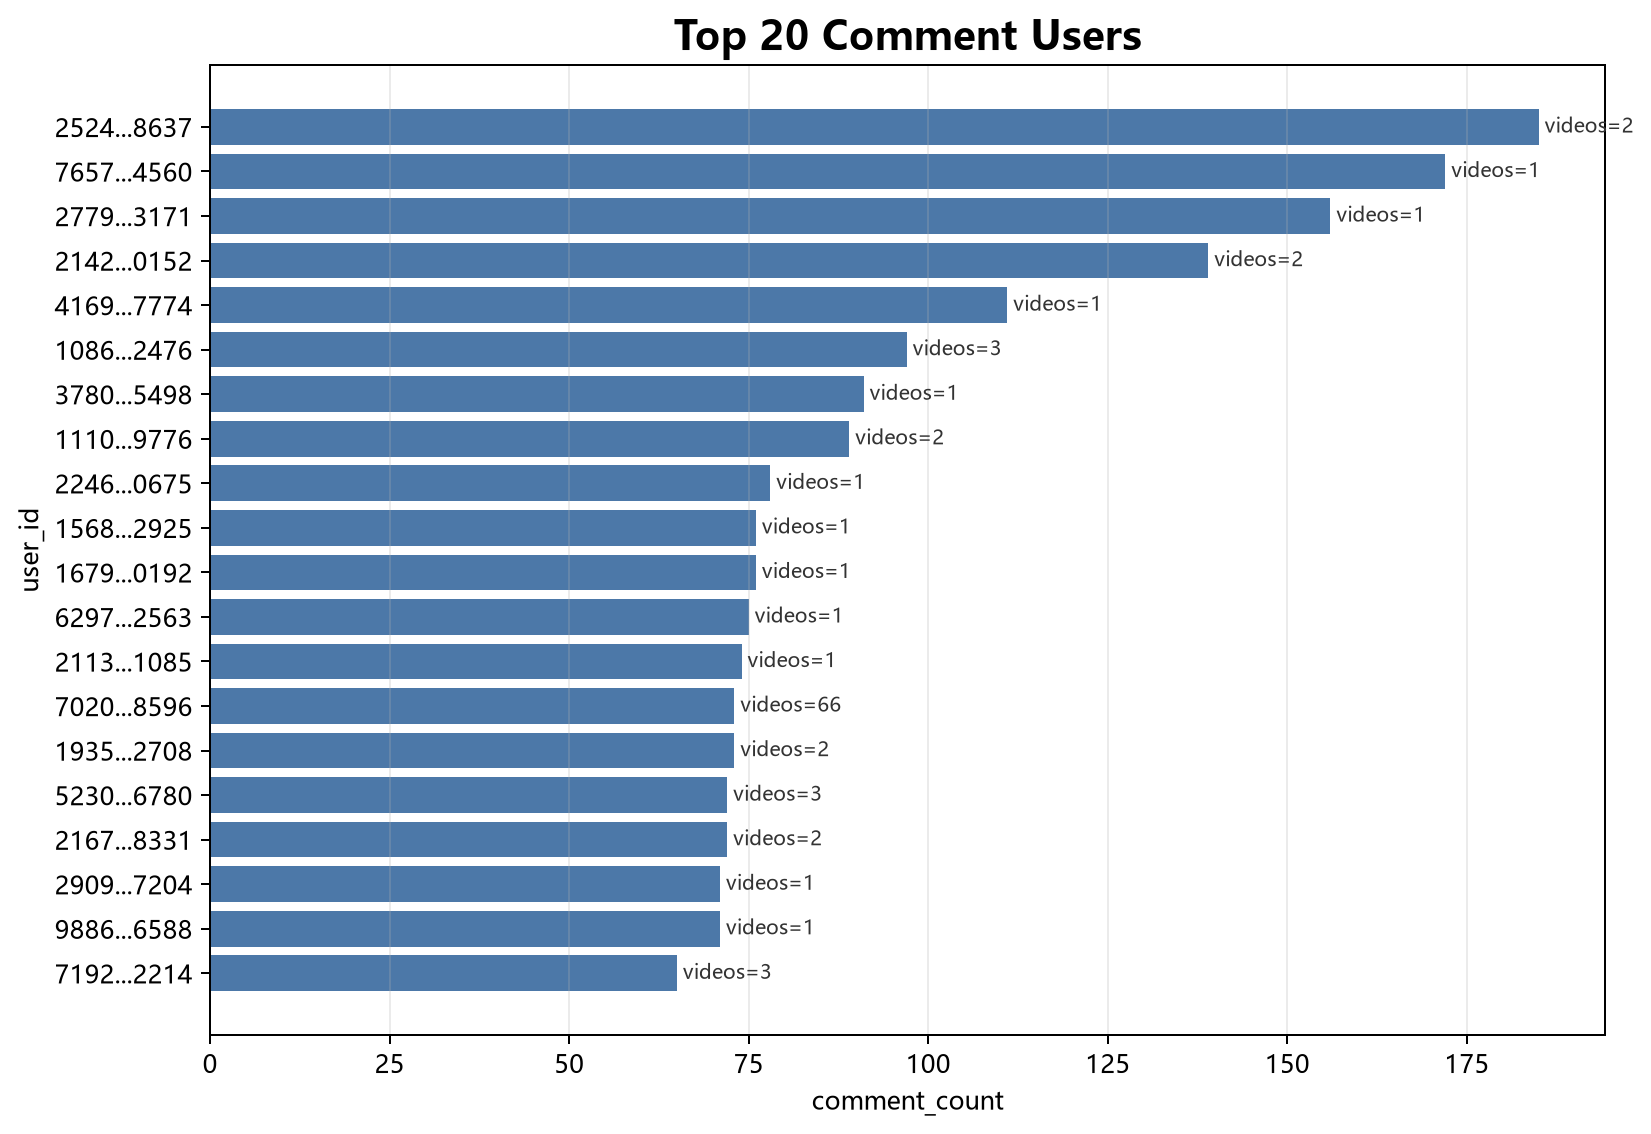

In [17]:
show_image(NETWORK_VIZ / 'user_role_counts.png', width=800)
show_image(NETWORK_VIZ / 'user_activity_scatter.png', width=800)
show_image(NETWORK_VIZ / 'top_comment_users.png', width=900)

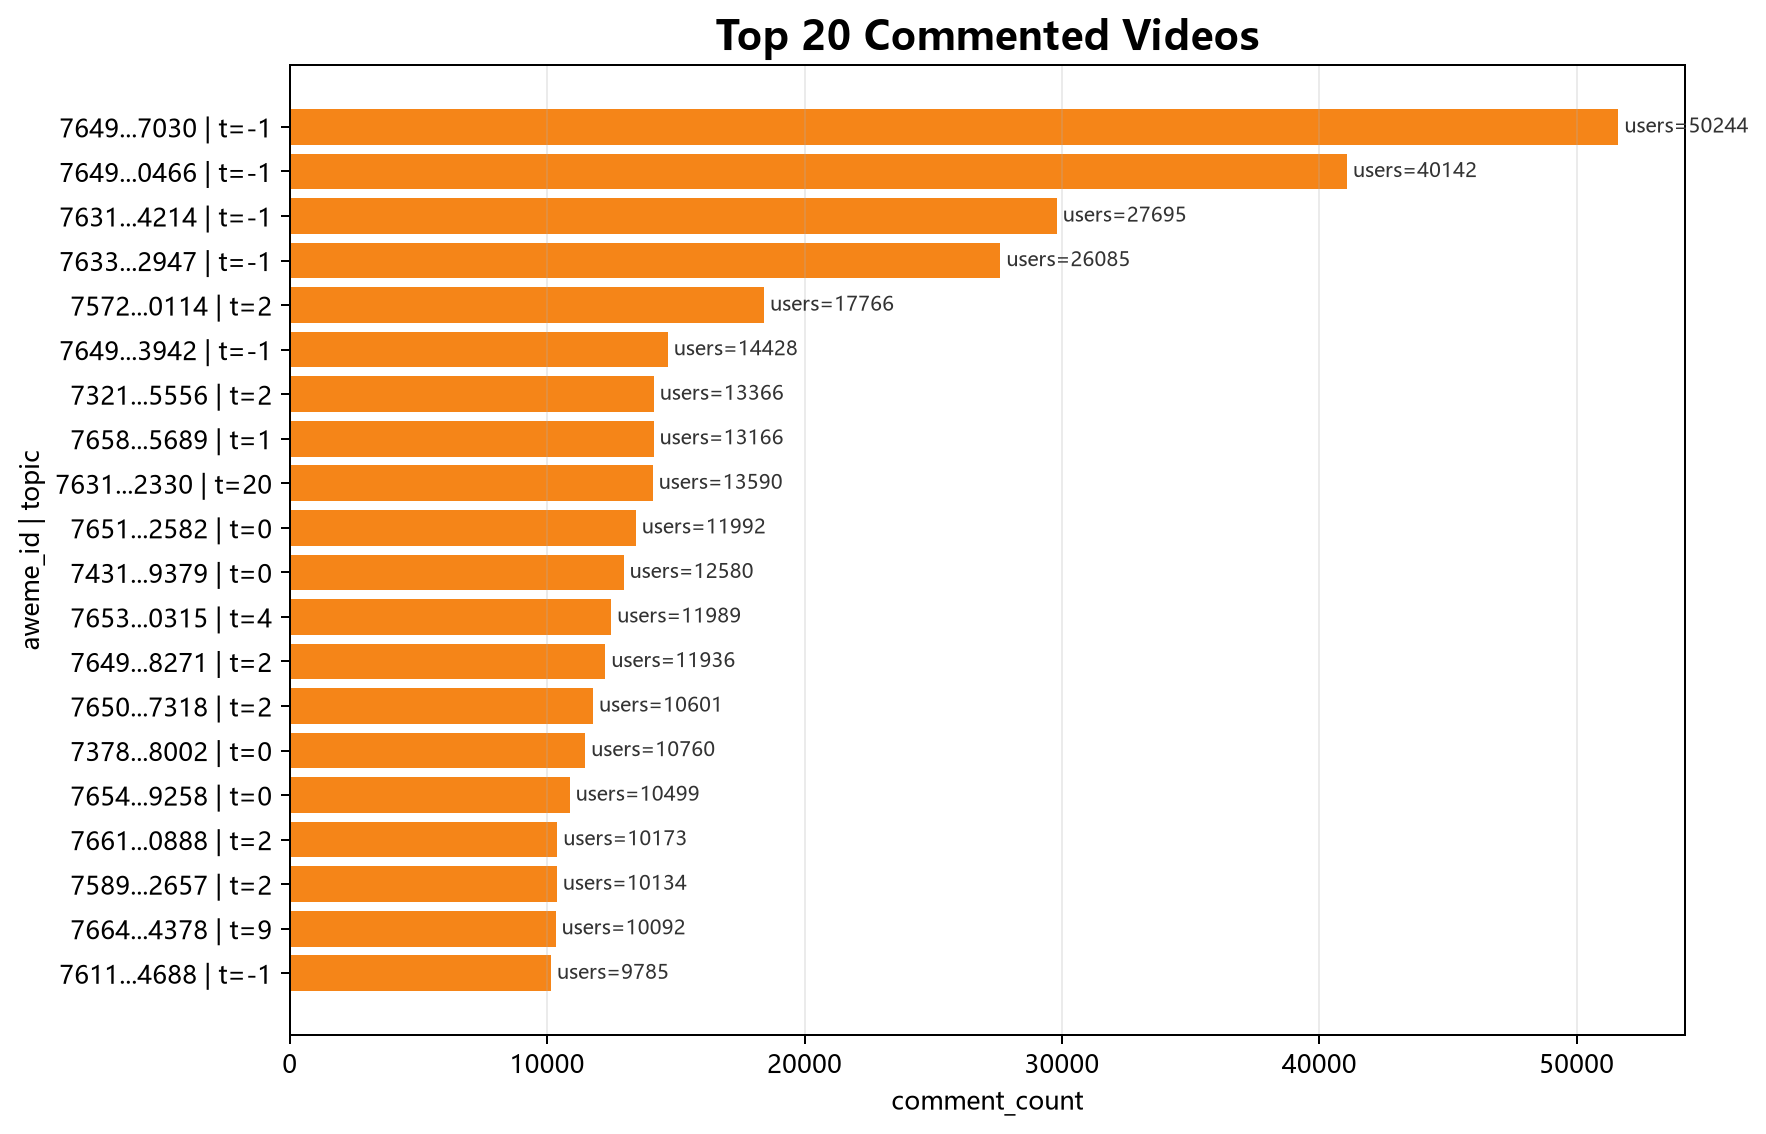

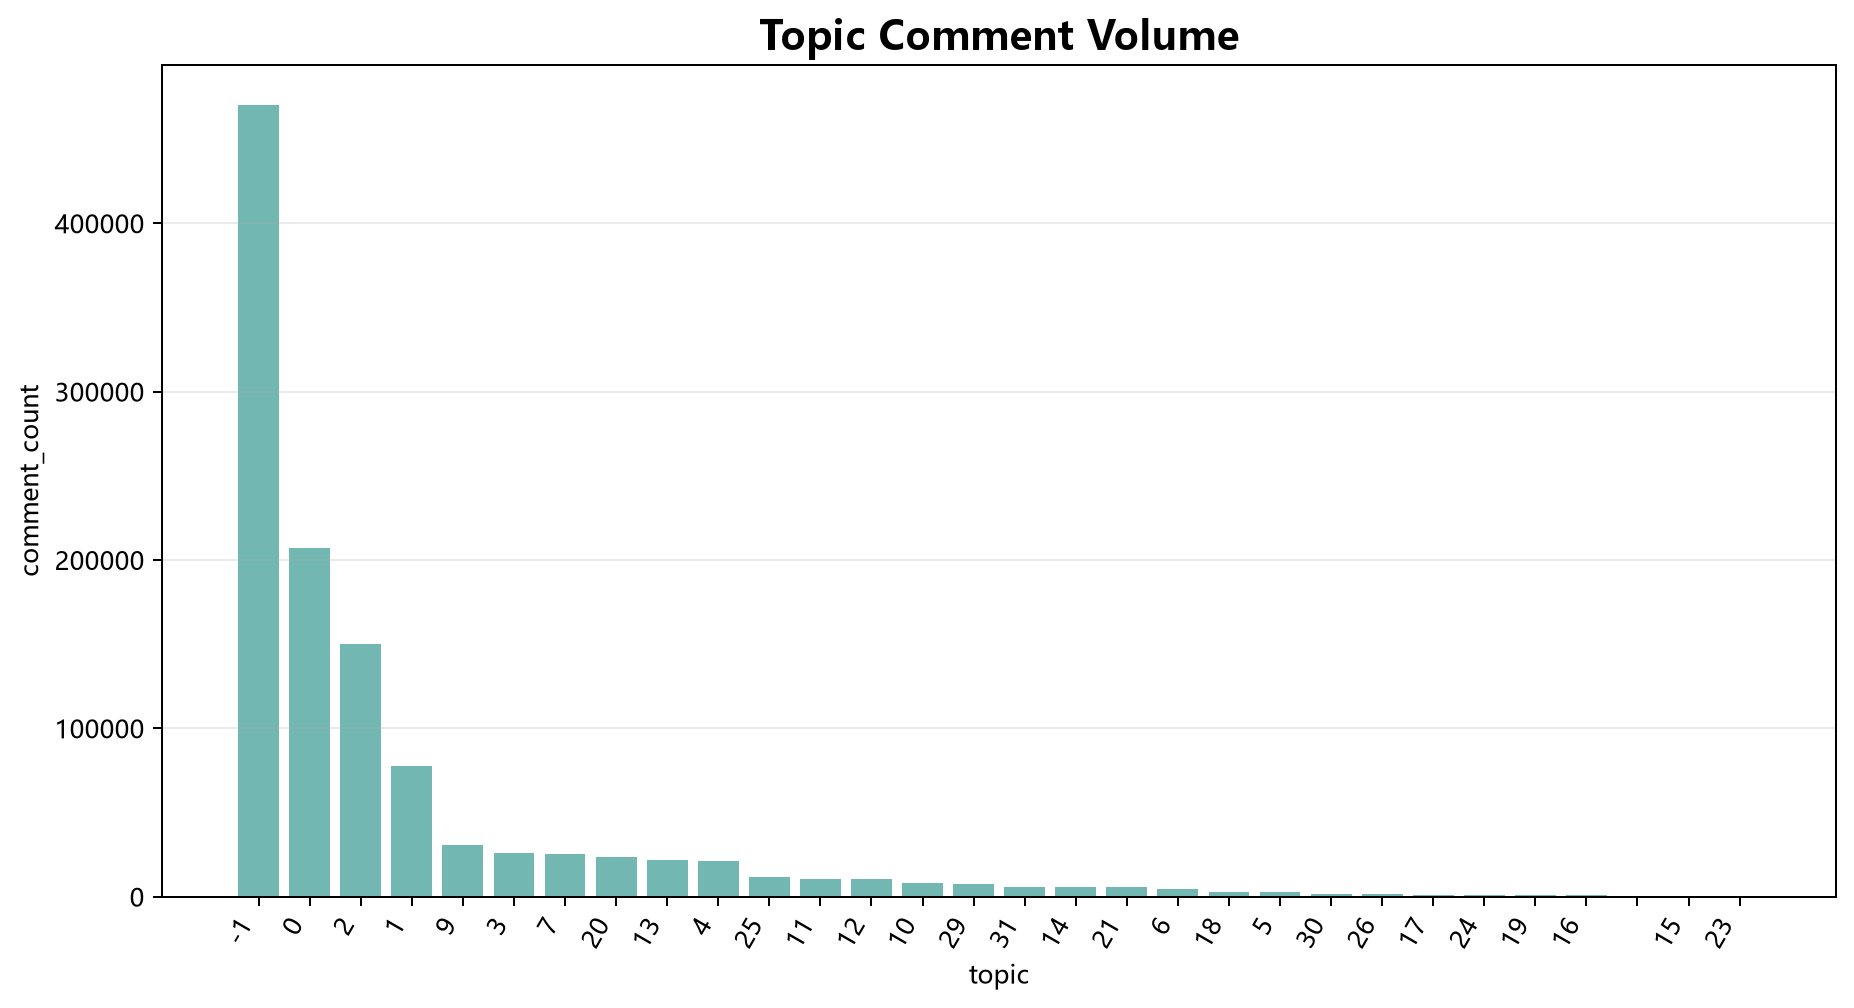

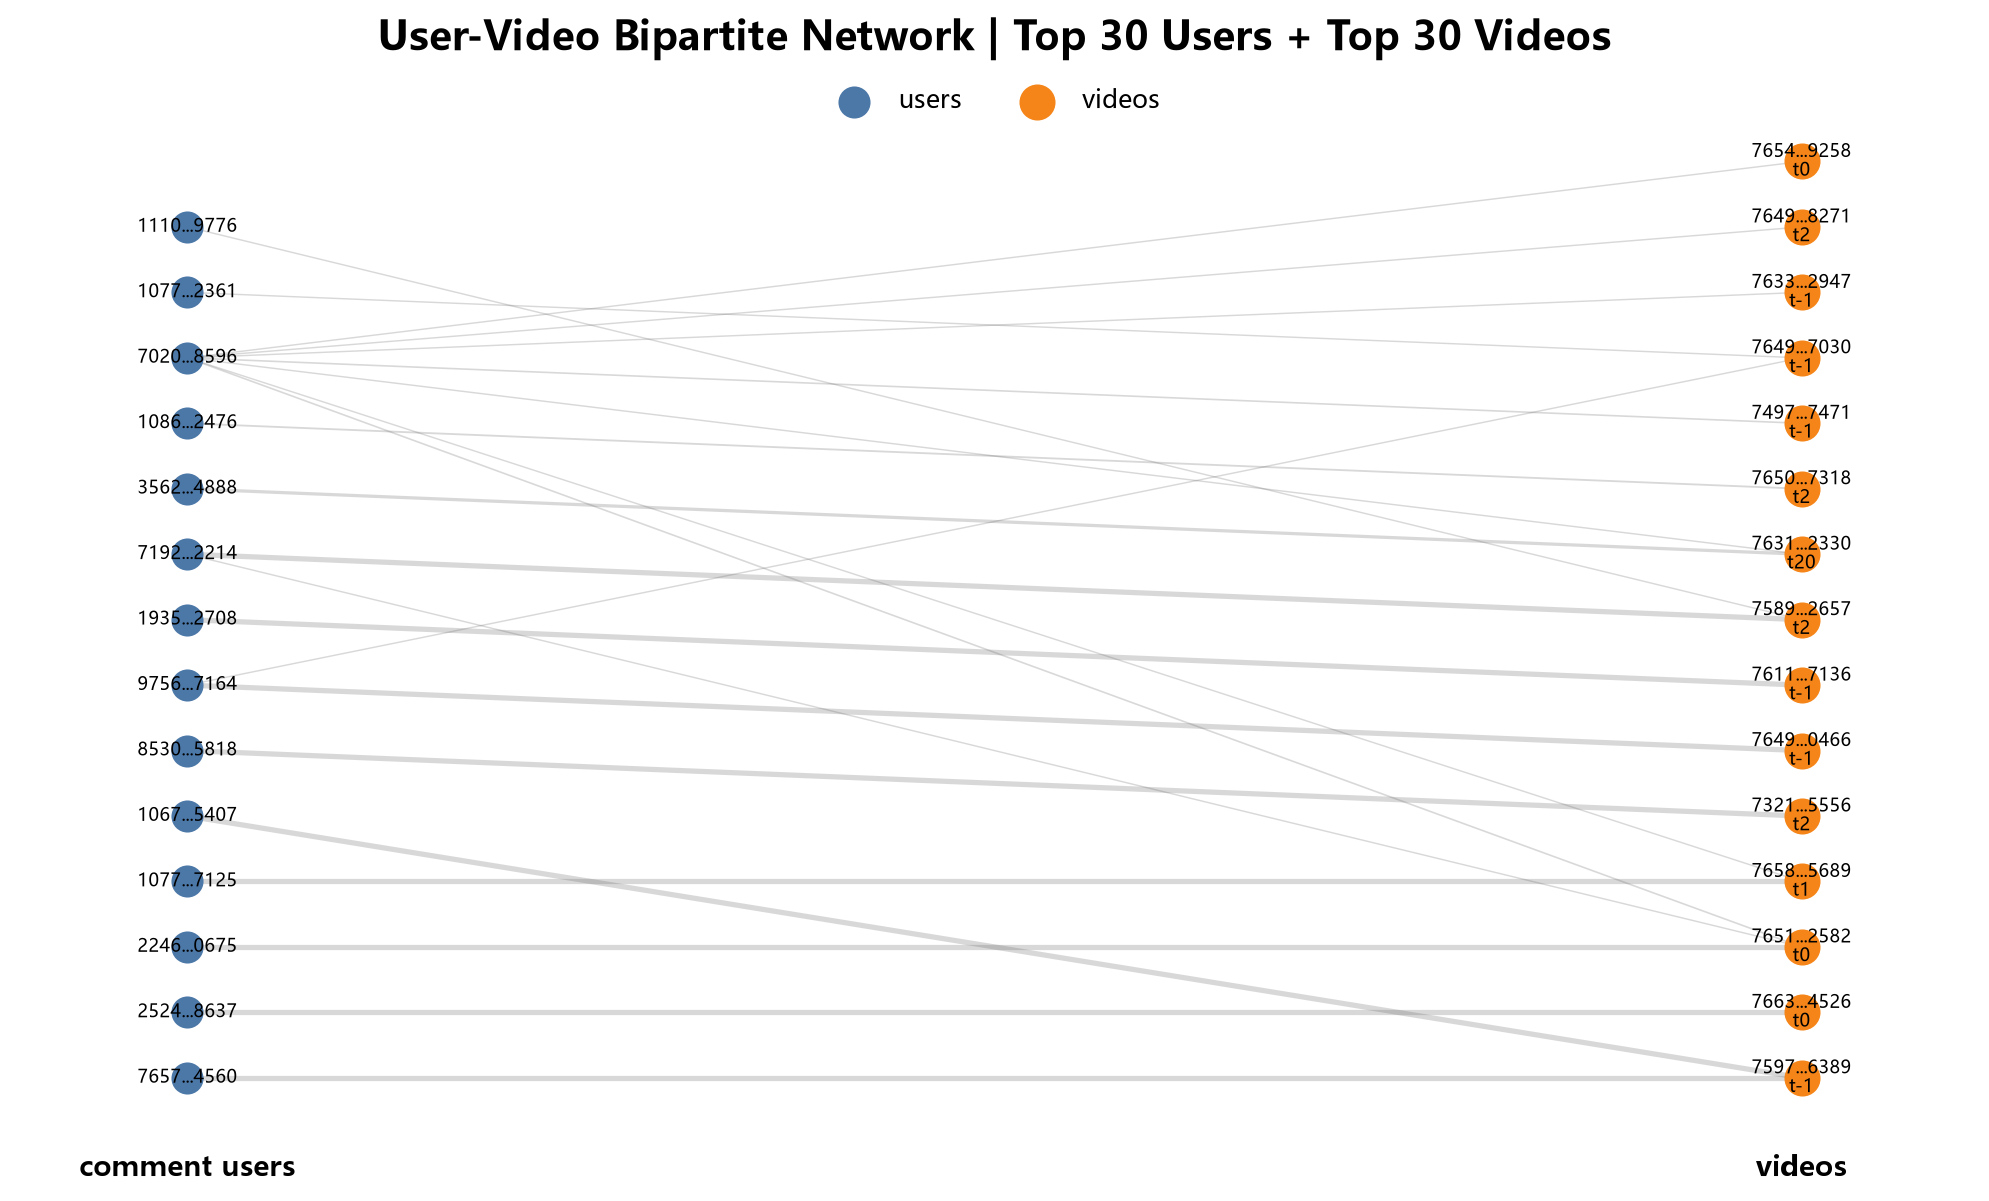

In [14]:
show_image(NETWORK_VIZ / 'top_commented_videos.png', width=900)
show_image(NETWORK_VIZ / 'topic_comment_volume.png', width=1000)
show_image(NETWORK_VIZ / 'user_video_bipartite_top_network.png', width=1000)

## 6. 关于网络层观察

- 大多数参与者是 `comment_only`，既发帖又评论的用户数量较少。
- `topic=-1` 虽然是噪声类，但包含大量评论，暂时保留，避免误删潜在相关视频。
- topic 8、22、27、28 已被人工判定为明显无关，并通过 `include_in_analysis=false` 排除出后续分析。
- 用户-视频边表可以观察一个用户是否在单个视频下反复评论，或是否跨多个视频参与讨论（8596）。